# Importing LIbiries 

In [97]:
# ── CORE LIBRARIES ────────────────────────────────────
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── SCIKIT-LEARN: MODEL SELECTION ─────────────────────
from sklearn.model_selection import train_test_split

# ── SCIKIT-LEARN: PREPROCESSING ───────────────────────
from sklearn.preprocessing import StandardScaler

# ── SCIKIT-LEARN: REGRESSION MODELS ───────────────────
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# ── SCIKIT-LEARN: CLASSIFICATION MODELS ───────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

# ── XGBOOST ───────────────────────────────────────────
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# ── LIGHTGBM ──────────────────────────────────────────
import lightgbm as lgb

# ── METRICS: REGRESSION ───────────────────────────────
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# ── METRICS: CLASSIFICATION ───────────────────────────
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ── VERSION CHECK ─────────────────────────────────────
import sklearn

print("✅ All imports loaded successfully!")
print("Scikit-Learn Version:", sklearn.__version__)

✅ All imports loaded successfully!
Scikit-Learn Version: 1.8.0


# Importing the dataset files 

In [3]:
nykaa = pd.read_csv(r'C:\Users\Saroon\Downloads\nykaa_campaign_data_with_nulls.csv')
purplle = pd.read_csv(r"C:\Users\Saroon\Downloads\purplle_campaign_data_with_nulls.csv")
tira = pd.read_csv(r"C:\Users\Saroon\Downloads\tira_campaign_data_with_nulls.csv")


### nykaa understing the nyka data set 


In [4]:
nykaa.head(2)
nykaa.info()
nykaa.shape
nykaa.isnull().sum()
nykaa.describe()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  str    
 1   Campaign_Type     52696 non-null  str    
 2   Target_Audience   52794 non-null  str    
 3   Duration          52665 non-null  float64
 4   Channel_Used      52750 non-null  str    
 5   Impressions       52775 non-null  float64
 6   Clicks            52773 non-null  float64
 7   Leads             52776 non-null  float64
 8   Conversions       52889 non-null  float64
 9   Revenue           52743 non-null  float64
 10  Acquisition_Cost  52742 non-null  float64
 11  ROI               52730 non-null  float64
 12  Language          52787 non-null  str    
 13  Engagement_Score  52806 non-null  float64
 14  Customer_Segment  52767 non-null  str    
 15  Date              52797 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,52665.000000,52775.000000,52773.000000,52776.000000,52889.000000,5.274300e+04,52742.000000,52730.000000,52806.000000
mean,17.444508,55119.386698,4690.636879,1876.938684,1033.357239,5.156704e+05,377.587214,2.718973,13.781463
std,7.515052,25913.116620,3178.575040,1435.723927,863.080820,4.900234e+05,542.150864,4.492699,6.351002
min,5.000000,10001.000000,202.000000,56.000000,20.000000,6.183000e+03,9.430000,-0.970000,2.600000
25%,11.000000,32748.000000,2113.000000,778.000000,400.000000,1.773790e+05,105.150000,0.040000,8.360000
50%,17.000000,55189.000000,3909.000000,1479.000000,778.000000,3.598320e+05,207.230000,1.250000,13.610000
75%,24.000000,77535.500000,6697.000000,2606.000000,1415.000000,6.881200e+05,428.500000,3.630000,18.850000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


### purplle understing the nyka data set 


In [5]:
purplle.head(2)
purplle.shape
purplle.info()
purplle.isnull().sum()
purplle.describe()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52871 non-null  str    
 1   Campaign_Type     52765 non-null  str    
 2   Target_Audience   52808 non-null  str    
 3   Duration          52787 non-null  float64
 4   Channel_Used      52811 non-null  str    
 5   Impressions       52834 non-null  float64
 6   Clicks            52843 non-null  float64
 7   Leads             52901 non-null  float64
 8   Conversions       52881 non-null  float64
 9   Revenue           52792 non-null  float64
 10  Acquisition_Cost  52857 non-null  float64
 11  ROI               52824 non-null  float64
 12  Language          52810 non-null  str    
 13  Engagement_Score  52953 non-null  float64
 14  Customer_Segment  52879 non-null  str    
 15  Date              52904 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,52787.000000,52834.000000,52843.000000,52901.000000,52881.000000,5.279200e+04,52857.000000,52824.000000,52953.000000
mean,17.487279,55081.247398,4682.958973,1873.141907,1027.354324,5.135680e+05,377.986979,2.681688,13.756857
std,7.492281,25955.720822,3179.537407,1432.215726,857.583756,4.876494e+05,536.908374,4.474675,6.334863
min,5.000000,10001.000000,207.000000,48.000000,19.000000,6.061000e+03,9.340000,-0.970000,2.560000
25%,11.000000,32658.500000,2111.000000,781.000000,399.000000,1.770750e+05,107.380000,0.040000,8.340000
50%,17.000000,55134.000000,3901.000000,1474.000000,772.000000,3.578840e+05,210.120000,1.220000,13.570000
75%,24.000000,77700.000000,6705.500000,2597.000000,1402.000000,6.867660e+05,431.880000,3.550000,18.790000
max,30.000000,100000.000000,14888.000000,8613.000000,6221.000000,4.345920e+06,12109.050000,66.840000,30.990000


### tira understing the nyka data set 


In [6]:
tira.head(2)
tira.shape
tira.info()
tira.isnull().sum()
tira.describe()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52822 non-null  str    
 1   Campaign_Type     52846 non-null  str    
 2   Target_Audience   52891 non-null  str    
 3   Duration          52890 non-null  float64
 4   Channel_Used      52822 non-null  str    
 5   Impressions       52832 non-null  float64
 6   Clicks            52825 non-null  float64
 7   Leads             52898 non-null  float64
 8   Conversions       52895 non-null  float64
 9   Revenue           52826 non-null  float64
 10  Acquisition_Cost  52905 non-null  float64
 11  ROI               52813 non-null  float64
 12  Language          52769 non-null  str    
 13  Engagement_Score  52825 non-null  float64
 14  Customer_Segment  52844 non-null  str    
 15  Date              52865 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,52890.000000,52832.000000,52825.000000,52898.000000,52895.000000,5.282600e+04,52905.000000,52813.000000,52825.000000
mean,17.533768,55005.698421,4681.332343,1866.431831,1024.783325,5.122444e+05,374.920868,2.687977,13.756235
std,7.497857,26016.433598,3174.005400,1422.867526,852.359561,4.851018e+05,531.010003,4.488936,6.298586
min,5.000000,10001.000000,208.000000,50.000000,17.000000,3.895000e+03,8.180000,-0.990000,2.580000
25%,11.000000,32426.000000,2108.000000,778.000000,402.000000,1.780650e+05,107.480000,0.060000,8.430000
50%,18.000000,54980.000000,3912.000000,1475.000000,775.000000,3.590540e+05,208.710000,1.240000,13.570000
75%,24.000000,77513.250000,6681.000000,2596.750000,1391.000000,6.822630e+05,425.880000,3.560000,18.720000
max,30.000000,99999.000000,14944.000000,8761.000000,6415.000000,4.517478e+06,15038.000000,79.300000,30.520000


### Adding new column for each dataset as per their name  befor merging 


In [7]:
nykaa.insert(1, 'Brand', 'Nykaa')
nykaa.head(2)

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,06-04-2025


In [8]:
purplle.insert(1, 'Brand', 'Purplle')
tira.insert(1, 'Brand', 'Tira')

In [9]:
purplle.head(2)
tira.head(2)

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,TI-CMP-1000,Tira,SEO,Working Women,11.0,NaN,64004.0,2906.0,1639.0,952.0,222768.0,129.72,0.80,Tamil,NaN,Premium Shoppers,30-10-2024
1,TI-CMP-1001,Tira,Social Media,Tier 2 City Customers,24.0,YouTube,71795.0,2051.0,552.0,256.0,199168.0,316.36,1.46,Tamil,3.98,College Students,11-09-2024


In [10]:
combined_data = pd.concat([nykaa, purplle, tira], ignore_index=True)
combined_data.head(2)
combined_data.shape

(166665, 17)

In [11]:
combined_data.head(2)


,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,06-04-2025


In [12]:
combined_data['Date'] = pd.to_datetime(combined_data['Date'], format='%d-%m-%Y')
combined_data

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,2025-04-06
2,NY-CMP-1002,Nykaa,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,NaN,English,25.03,College Students,2025-01-14
3,NY-CMP-1003,Nykaa,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,NaN,2025-06-04
4,NY-CMP-1004,Nykaa,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,NaN,Tira,NaN,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",NaN,3799.0,NaN,1099.0,454986.0,213.21,0.94,Bengali,10.70,Youth,2024-11-12
166661,TI-CMP-56551,Tira,SEO,Working Women,20.0,"Google, Instagram",54886.0,1578.0,634.0,NaN,136514.0,436.24,-0.09,English,4.66,Working Women,2024-08-25
166662,TI-CMP-56552,Tira,Email,NaN,13.0,"Facebook, Instagram",97954.0,11480.0,4567.0,2144.0,445952.0,78.77,1.64,NaN,18.57,Premium Shoppers,2025-04-15
166663,NaN,Tira,Influencer,Premium Shoppers,22.0,"Google, Email",11669.0,NaN,122.0,44.0,26884.0,NaN,-0.76,English,5.35,Working Women,2024-07-21


### changing null value from revenue to 0

In [13]:
combined_data['Revenue'] = combined_data['Revenue'].fillna(0)
combined_data[combined_data['Revenue'].isnull()]

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date


In [14]:
mean_val = combined_data['Acquisition_Cost'].mean()
combined_data['Acquisition_Cost'] = combined_data['Acquisition_Cost'].fillna(mean_val)
combined_data[combined_data['Acquisition_Cost'].isnull()]
print(f"✅ Acquisition_Cost → filled with mean: {mean_val:.2f}")

✅ Acquisition_Cost → filled with mean: 376.83


### changing null value from language  to native 

In [15]:
combined_data['Language'] = combined_data['Language'].fillna('Native')
combined_data['Customer_Segment'] = combined_data['Customer_Segment'].fillna('Basic Plan')

### changing null value from', 'Campaign_Type', 'Target_Audience','Channel_Used', as Mode 

In [16]:

categorical_cols = ['Campaign_Type', 'Target_Audience',
                    'Channel_Used']
for col in categorical_cols:
    mode_val = combined_data[col].mode()[0]
    combined_data[col] = combined_data[col].fillna(mode_val)
    
    print(f"✅ {col} → filled with mode: {mode_val}")
    


✅ Campaign_Type → filled with mode: Influencer
✅ Target_Audience → filled with mode: Premium Shoppers
✅ Channel_Used → filled with mode: Email


### numeric colume  as median 

In [17]:
numerical_cols = ['Duration', 'Impressions', 'Clicks', 'Leads', 
                  'Conversions', 'Engagement_Score']

for col in numerical_cols:
    median_val = combined_data[col].median()
    combined_data[col] = combined_data[col].fillna(median_val)
    print(f"✅ {col} → filled with median: {median_val:.2f}")

✅ Duration → filled with median: 17.00
✅ Impressions → filled with median: 55113.00
✅ Clicks → filled with median: 3908.00
✅ Leads → filled with median: 1476.00
✅ Conversions → filled with median: 775.00
✅ Engagement_Score → filled with median: 13.59


In [18]:
combined_data.head(2)

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,376.83056,6.14,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83000,3.26,Hindi,7.24,College Students,2025-04-06


In [19]:
combined_data.isnull().sum()

Campaign_ID         5417
Brand                  0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                 8298
Language               0
Engagement_Score       0
Customer_Segment       0
Date                8099
dtype: int64

In [20]:
combined_data.duplicated().sum()

np.int64(0)

### create new column as Updated_ROI as current ROI seems wrong 

In [21]:
combined_data['Updated_ROI'] = (
    (combined_data['Revenue'] - combined_data['Acquisition_Cost'])
    / combined_data['Acquisition_Cost']
).round(2)
combined_data.head(2)

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date,Updated_ROI
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,376.83056,6.14,Hindi,20.98,College Students,2025-04-29,4954.85
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83000,3.26,Hindi,7.24,College Students,2025-04-06,5784.80


### moving the colum near to old ROI 

In [22]:
roi_pos = combined_data.columns.get_loc('ROI')
col = combined_data.pop('Updated_ROI')
combined_data.insert(roi_pos + 1, 'Updated_ROI', col)
combined_data.isnull().sum()

Campaign_ID         5417
Brand                  0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                 8298
Updated_ROI            0
Language               0
Engagement_Score       0
Customer_Segment       0
Date                8099
dtype: int64

### replace 0.00 in old ROI data to avoid nul values 

In [23]:
combined_data['ROI'] = combined_data['ROI'].fillna('0.00')

### Spliting the Channel_Used into multiple column 

In [24]:
# Cell 1 — Find unique channels
all_channels = (
    combined_data['Channel_Used'].str.split(',').explode().str.strip().unique())

sorted(all_channels)
print("Total unique channels:", len(all_channels))

Total unique channels: 6


In [25]:
channel_dummies = combined_data['Channel_Used'].str.get_dummies(sep=', ')
channel_dummies
channel_dummies.columns.tolist()

['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']

In [26]:
channel_pos = combined_data.columns.get_loc('Channel_Used')
for i, col in enumerate(channel_dummies.columns):
    combined_data.insert(channel_pos + 1 + i, col, channel_dummies[col])
combined_data.head(2)

,Campaign_ID,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Email,Facebook,Google,Instagram,...,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Updated_ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",0,0,0,0,...,3616.0,2355.0,1867515.0,376.83056,6.14,4954.85,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,0,0,0,0,...,1971.0,1357.0,1046247.0,180.83000,3.26,5784.80,Hindi,7.24,College Students,2025-04-06


In [27]:
combined_data.drop(columns=['Campaign_ID'], inplace=True)


In [28]:
combined_data.drop(columns=['ROI'], inplace=True)

In [29]:
combined_data.isnull().sum()

Brand                  0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Email                  0
Facebook               0
Google                 0
Instagram              0
WhatsApp               0
YouTube                0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
Updated_ROI            0
Language               0
Engagement_Score       0
Customer_Segment       0
Date                8099
dtype: int64

In [30]:
combined_data

,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Email,Facebook,Google,Instagram,WhatsApp,...,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Language,Engagement_Score,Customer_Segment,Date
0,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",0,0,0,0,1,...,6156.0,3616.0,2355.0,1867515.0,376.83056,4954.85,Hindi,20.98,College Students,2025-04-29
1,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,0,0,0,0,0,...,3321.0,1971.0,1357.0,1046247.0,180.83000,5784.80,Hindi,7.24,College Students,2025-04-06
2,Nykaa,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",0,0,1,0,1,...,2182.0,952.0,755.0,197055.0,90.60000,2174.00,English,25.03,College Students,2025-01-14
3,Nykaa,Email,Working Women,18.0,"YouTube, Facebook, Instagram",0,1,0,1,0,...,8413.0,2231.0,947.0,376906.0,249.07000,1512.25,Hindi,13.15,Basic Plan,2025-06-04
4,Nykaa,Paid Ads,College Students,10.0,"Facebook, Instagram",0,1,0,1,0,...,3743.0,2060.0,1258.0,518296.0,228.60000,2266.26,Hindi,7.29,Tier 2 City Customers,2024-12-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,Tira,Influencer,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",1,0,0,1,0,...,3799.0,1476.0,1099.0,454986.0,213.21000,2132.98,Bengali,10.70,Youth,2024-11-12
166661,Tira,SEO,Working Women,20.0,"Google, Instagram",0,0,1,1,0,...,1578.0,634.0,775.0,136514.0,436.24000,311.93,English,4.66,Working Women,2024-08-25
166662,Tira,Email,Premium Shoppers,13.0,"Facebook, Instagram",0,1,0,1,0,...,11480.0,4567.0,2144.0,445952.0,78.77000,5660.44,Native,18.57,Premium Shoppers,2025-04-15
166663,Tira,Influencer,Premium Shoppers,22.0,"Google, Email",1,0,1,0,0,...,3908.0,122.0,44.0,26884.0,376.83056,70.34,English,5.35,Working Women,2024-07-21


### updating random date in dates

In [31]:
null_count = combined_data['Date'].isnull().sum()
null_count

np.int64(8099)

In [32]:
existing_dates = combined_data['Date'].dropna()

In [33]:
np.random.seed(42)
random_dates = existing_dates.sample(n=null_count, replace=True).values
print(f"Generated {len(random_dates)} random dates")
print(f"Sample of generated dates: {random_dates[:5]}")

Generated 8099 random dates
Sample of generated dates: ['2024-07-09T00:00:00.000000' '2024-12-03T00:00:00.000000'
 '2024-08-26T00:00:00.000000' '2024-07-28T00:00:00.000000'
 '2024-07-24T00:00:00.000000']


In [34]:
combined_data.loc[combined_data['Date'].isnull(), 'Date'] = random_dates

In [35]:
combined_data['Date'].isnull().sum()
combined_data['Date'].min(), "→", combined_data['Date'].max()

(Timestamp('2024-07-01 00:00:00'), '→', Timestamp('2025-06-24 00:00:00'))

In [36]:
combined_data['Date']

0        2025-04-29
1        2025-04-06
2        2025-01-14
3        2025-06-04
4        2024-12-29
            ...    
166660   2024-11-12
166661   2024-08-25
166662   2025-04-15
166663   2024-07-21
166664   2025-05-02
Name: Date, Length: 166665, dtype: datetime64[us]

In [37]:
combined_data

,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Email,Facebook,Google,Instagram,WhatsApp,...,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Language,Engagement_Score,Customer_Segment,Date
0,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",0,0,0,0,1,...,6156.0,3616.0,2355.0,1867515.0,376.83056,4954.85,Hindi,20.98,College Students,2025-04-29
1,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,0,0,0,0,0,...,3321.0,1971.0,1357.0,1046247.0,180.83000,5784.80,Hindi,7.24,College Students,2025-04-06
2,Nykaa,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",0,0,1,0,1,...,2182.0,952.0,755.0,197055.0,90.60000,2174.00,English,25.03,College Students,2025-01-14
3,Nykaa,Email,Working Women,18.0,"YouTube, Facebook, Instagram",0,1,0,1,0,...,8413.0,2231.0,947.0,376906.0,249.07000,1512.25,Hindi,13.15,Basic Plan,2025-06-04
4,Nykaa,Paid Ads,College Students,10.0,"Facebook, Instagram",0,1,0,1,0,...,3743.0,2060.0,1258.0,518296.0,228.60000,2266.26,Hindi,7.29,Tier 2 City Customers,2024-12-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,Tira,Influencer,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",1,0,0,1,0,...,3799.0,1476.0,1099.0,454986.0,213.21000,2132.98,Bengali,10.70,Youth,2024-11-12
166661,Tira,SEO,Working Women,20.0,"Google, Instagram",0,0,1,1,0,...,1578.0,634.0,775.0,136514.0,436.24000,311.93,English,4.66,Working Women,2024-08-25
166662,Tira,Email,Premium Shoppers,13.0,"Facebook, Instagram",0,1,0,1,0,...,11480.0,4567.0,2144.0,445952.0,78.77000,5660.44,Native,18.57,Premium Shoppers,2025-04-15
166663,Tira,Influencer,Premium Shoppers,22.0,"Google, Email",1,0,1,0,0,...,3908.0,122.0,44.0,26884.0,376.83056,70.34,English,5.35,Working Women,2024-07-21


## EDA

In [38]:
# Save cleaned combined_data to a new CSV file
combined_data.to_csv(r'C:\Users\Saroon\Downloads\cleaned_combined_data.csv', index=False)

print("✅ File saved successfully!")
print("Shape:", combined_data.shape)
print("Columns:", combined_data.columns.tolist())

✅ File saved successfully!
Shape: (166665, 22)
Columns: ['Brand', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'Updated_ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date']


In [39]:
combined_data = pd.read_csv(r'C:\Users\Saroon\Downloads\cleaned_combined_data.csv')


In [40]:
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

In [41]:
# Convert Date to datetime first
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

# Create only Month_Name in Apr'25 format
combined_data['Month_Name'] = combined_data['Date'].dt.strftime("%b'%y")

# Verify
print(combined_data[['Date', 'Month_Name']].head(10))

        Date Month_Name
0 2025-04-29     Apr'25
1 2025-04-06     Apr'25
2 2025-01-14     Jan'25
3 2025-06-04     Jun'25
4 2024-12-29     Dec'24
5 2024-09-23     Sep'24
6 2024-09-01     Sep'24
7 2025-05-31     May'25
8 2025-03-24     Mar'25
9 2025-04-29     Apr'25


In [42]:
combined_data

,Brand,Campaign_Type,Target_Audience,Duration,Channel_Used,Email,Facebook,Google,Instagram,WhatsApp,...,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Language,Engagement_Score,Customer_Segment,Date,Month_Name
0,Nykaa,Social Media,College Students,21.0,"WhatsApp, YouTube",0,0,0,0,1,...,3616.0,2355.0,1867515.0,376.83056,4954.85,Hindi,20.98,College Students,2025-04-29,Apr'25
1,Nykaa,Paid Ads,Tier 2 City Customers,18.0,YouTube,0,0,0,0,0,...,1971.0,1357.0,1046247.0,180.83000,5784.80,Hindi,7.24,College Students,2025-04-06,Apr'25
2,Nykaa,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",0,0,1,0,1,...,952.0,755.0,197055.0,90.60000,2174.00,English,25.03,College Students,2025-01-14,Jan'25
3,Nykaa,Email,Working Women,18.0,"YouTube, Facebook, Instagram",0,1,0,1,0,...,2231.0,947.0,376906.0,249.07000,1512.25,Hindi,13.15,Basic Plan,2025-06-04,Jun'25
4,Nykaa,Paid Ads,College Students,10.0,"Facebook, Instagram",0,1,0,1,0,...,2060.0,1258.0,518296.0,228.60000,2266.26,Hindi,7.29,Tier 2 City Customers,2024-12-29,Dec'24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,Tira,Influencer,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",1,0,0,1,0,...,1476.0,1099.0,454986.0,213.21000,2132.98,Bengali,10.70,Youth,2024-11-12,Nov'24
166661,Tira,SEO,Working Women,20.0,"Google, Instagram",0,0,1,1,0,...,634.0,775.0,136514.0,436.24000,311.93,English,4.66,Working Women,2024-08-25,Aug'24
166662,Tira,Email,Premium Shoppers,13.0,"Facebook, Instagram",0,1,0,1,0,...,4567.0,2144.0,445952.0,78.77000,5660.44,Native,18.57,Premium Shoppers,2025-04-15,Apr'25
166663,Tira,Influencer,Premium Shoppers,22.0,"Google, Email",1,0,1,0,0,...,122.0,44.0,26884.0,376.83056,70.34,English,5.35,Working Women,2024-07-21,Jul'24


In [43]:
combined_data.drop(columns=['Channel_Used'], inplace=True)
combined_data.drop(columns=['Date'], inplace=True)

In [44]:
combined_data.isnull().sum()


Brand               0
Campaign_Type       0
Target_Audience     0
Duration            0
Email               0
Facebook            0
Google              0
Instagram           0
WhatsApp            0
YouTube             0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
Updated_ROI         0
Language            0
Engagement_Score    0
Customer_Segment    0
Month_Name          0
dtype: int64

In [45]:
combined_data.isnull().sum()
combined_data.describe()


,Duration,Email,Facebook,Google,Instagram,WhatsApp,YouTube,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Engagement_Score
count,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,1.666650e+05,166665.000000,166665.000000,166665.000000
mean,17.464183,0.366784,0.316887,0.316989,0.317343,0.316347,0.316689,55070.942483,4646.634590,1852.937011,1016.330177,4.882256e+05,376.830560,5878.534565,13.756366
std,7.312826,0.481928,0.465264,0.465305,0.465444,0.465052,0.465186,25313.049988,3102.538446,1397.723107,838.602514,4.882630e+05,523.396497,13787.010206,6.172954
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10001.000000,202.000000,48.000000,17.000000,0.000000e+00,8.180000,-1.000000,2.560000
25%,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33783.000000,2185.000000,809.000000,417.000000,1.545830e+05,111.100000,342.720000,8.650000
50%,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55113.000000,3908.000000,1476.000000,775.000000,3.357800e+05,222.920000,1468.710000,13.590000
75%,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,76427.000000,6510.000000,2525.000000,1357.000000,6.595050e+05,410.920000,5337.120000,18.530000
max,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100000.000000,14944.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,494114.400000,30.990000


In [46]:
combined_data.to_csv(r'C:\Users\Saroon\Downloads\cleaned_combined_data.csv', index=False)
print("✅ Saved!")
print("Shape:", combined_data.shape)
print("Columns:", combined_data.columns.tolist())

✅ Saved!
Shape: (166665, 21)
Columns: ['Brand', 'Campaign_Type', 'Target_Audience', 'Duration', 'Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'Updated_ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Month_Name']


# EDA and Visulazation 

A) Brand Analysis     → Nykaa vs Purplle vs Tira
B) Campaign Type      → which type performs best
C) Channel Analysis   → which platform wins
D) Audience Analysis  → who converts best
E) Correlation        → how numbers relate
F) Time Trends        → monthly patterns
G) All of the above   → full EDA in order

## Brand Analysis

### Setting style for charts 

In [47]:
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## Number of Campaigns per Brand

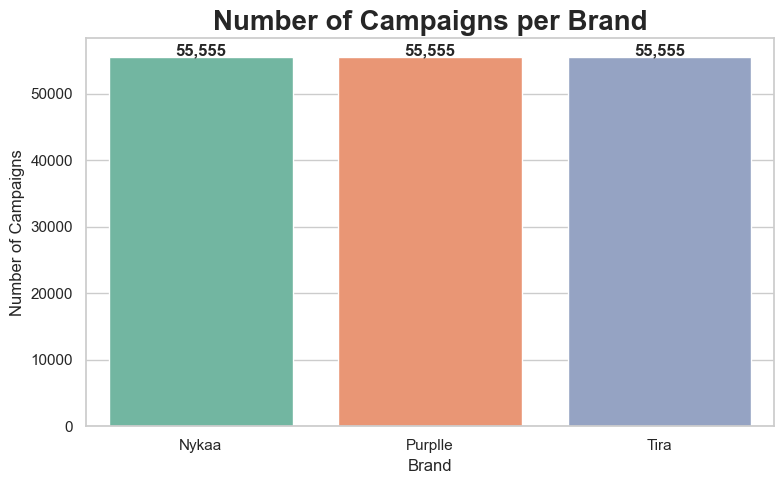

In [48]:
plt.figure(figsize=(8, 5 ))
brand_counts =combined_data['Brand'].value_counts()

sns.barplot(x=brand_counts.index, 
            y=brand_counts.values, 
            hue=brand_counts.index,    # ← add this
            palette='Set2', 
            legend=False) 
plt.title('Number of Campaigns per Brand', fontsize=20, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Number of Campaigns')
for i, v in  enumerate(brand_counts.values):
    plt.text(i,v+200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Total Revenue per Brand

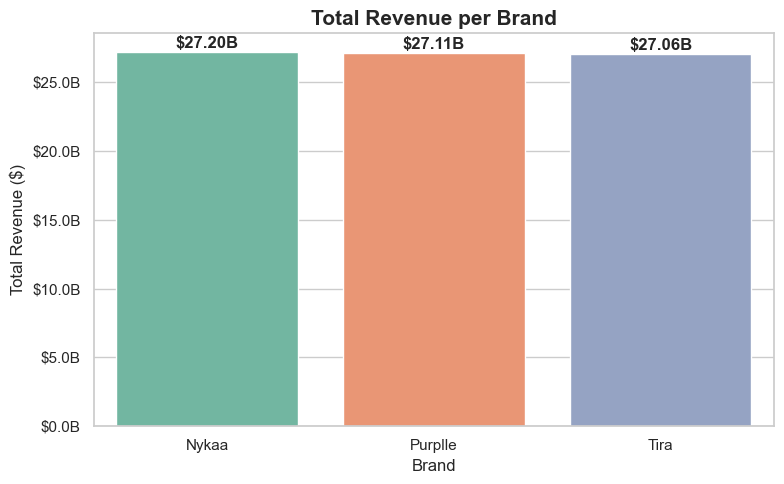


Total Revenue per Brand:
Brand
Nykaa      $27.20B
Purplle    $27.11B
Tira       $27.06B
Name: Revenue, dtype: str


In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
brand_revenue = combined_data.groupby('Brand')['Revenue'].sum().sort_values(ascending=False)

sns.barplot(x=brand_revenue.index, 
            y=brand_revenue.values, 
            hue=brand_revenue.index,
            palette='Set2', 
            legend=False)

plt.title('Total Revenue per Brand', fontsize=15, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Total Revenue ($)')

# Format y-axis to show Billions automatically
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

# Labels on top of bars
for i, v in enumerate(brand_revenue.values):
    plt.text(i, v * 1.01, f'${v/1e9:.2f}B', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTotal Revenue per Brand:")
print(brand_revenue.apply(lambda x: f'${x/1e9:.2f}B'))

## Average ROI per Brand

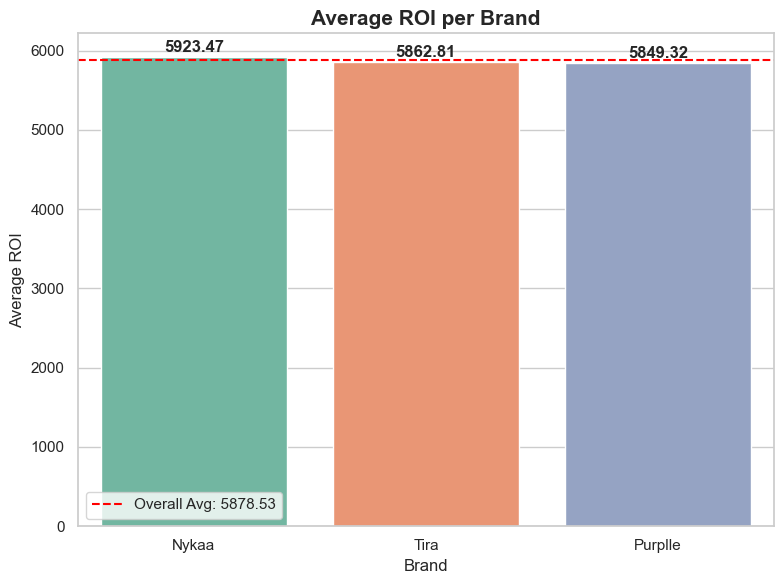


Average ROI per Brand:
Brand
Nykaa      5923.47
Tira       5862.81
Purplle    5849.32
Name: Updated_ROI, dtype: float64


In [50]:
fig,ax = plt.subplots(figsize=(8,6))
brand_roi = combined_data.groupby('Brand')['Updated_ROI'].mean().sort_values(ascending=False)
sns.barplot(x=brand_roi.index, 
            y=brand_roi.values, 
            hue=brand_roi.index,
            palette='Set2', 
            legend=False,
            ax=ax)

ax.set_title('Average ROI per Brand', fontsize=15, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Average ROI')

ax.axhline(y=brand_roi.mean(), color='red', linestyle='--', 
           label=f'Overall Avg: {brand_roi.mean():.2f}')
ax.legend()
for i, v in enumerate(brand_roi.values):
    ax.text(i, v * 1.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage ROI per Brand:")
print(brand_roi.round(2))

## Average Acquisition Cost per Brand

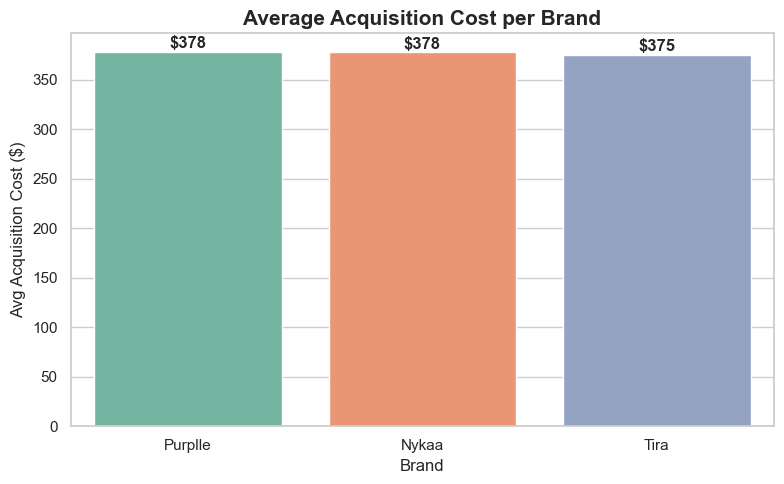


Average Acquisition Cost per Brand:
Brand
Purplle    377.93
Nykaa      377.55
Tira       375.01
Name: Acquisition_Cost, dtype: float64


In [51]:
fig, ax = plt.subplots(figsize=(8, 5))

brand_cost = combined_data.groupby('Brand')['Acquisition_Cost'].mean().sort_values(ascending=False)

sns.barplot(x=brand_cost.index, 
            y=brand_cost.values, 
            hue=brand_cost.index,
            palette='Set2', 
            legend=False,
            ax=ax)

ax.set_title('Average Acquisition Cost per Brand', fontsize=15, fontweight='bold')
ax.set_xlabel('Brand')
ax.set_ylabel('Avg Acquisition Cost ($)')

for i, v in enumerate(brand_cost.values):
    ax.text(i, v * 1.01, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Acquisition Cost per Brand:")
print(brand_cost.round(2))

## Revenue Share per Brand

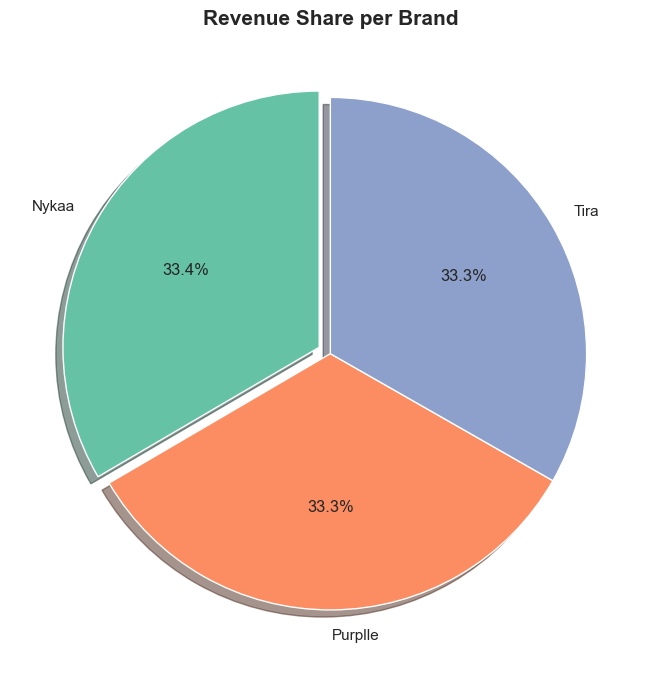

In [52]:
fig, ax = plt.subplots(figsize=(7, 7))

brand_revenue = combined_data.groupby('Brand')['Revenue'].sum()

ax.pie(brand_revenue.values, 
       labels=brand_revenue.index,
       autopct='%1.1f%%',        # show percentage on each slice
       startangle=90,            # start from top
       colors=['#66c2a5','#fc8d62','#8da0cb'],
       explode=(0.05, 0, 0),     # slightly pull out first slice
       shadow=True)

ax.set_title('Revenue Share per Brand', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Campaign Type Analysis

###  Campaign Type Distribution which type is used most 

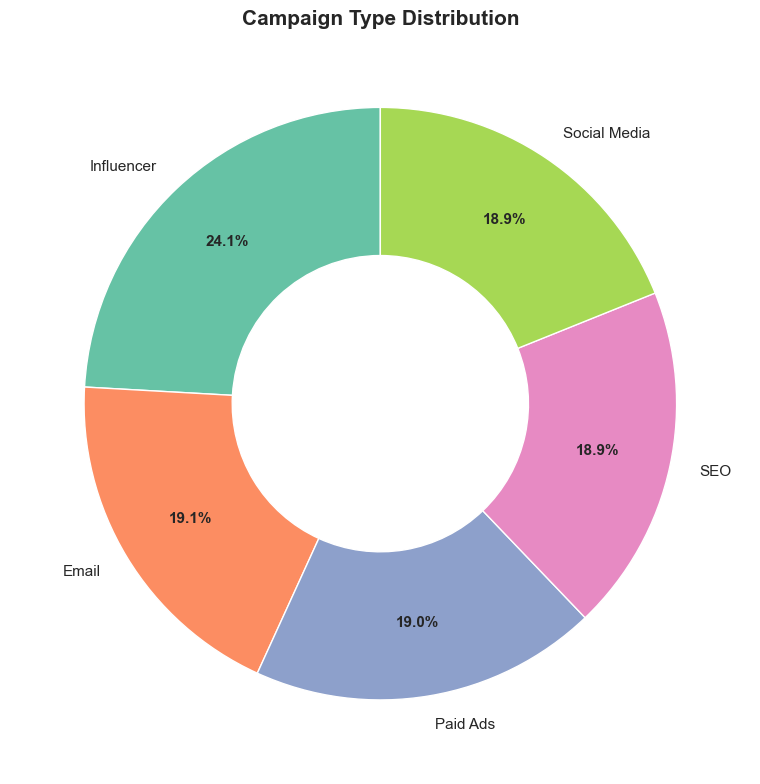

Campaign_Type
Influencer      40175
Email           31801
Paid Ads        31604
SEO             31570
Social Media    31515
Name: count, dtype: int64


In [53]:
fig, ax = plt.subplots(figsize=(8, 8))

campaign_counts = combined_data['Campaign_Type'].value_counts()

wedges, texts, autotexts = ax.pie(
    campaign_counts.values,
    labels=campaign_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(campaign_counts)),
    wedgeprops=dict(width=0.5),   # ← this makes it a DONUT
    pctdistance=0.75
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('Campaign Type Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(campaign_counts)

### Revenue by Campaign Type (Horizontal Bar)

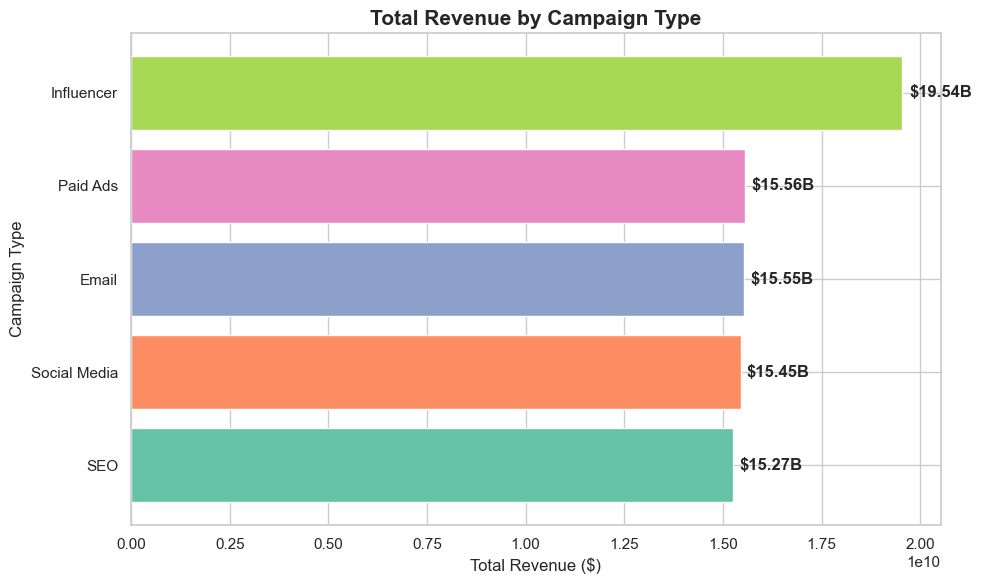


Revenue by Campaign Type:
Campaign_Type
SEO             $15.27B
Social Media    $15.45B
Email           $15.55B
Paid Ads        $15.56B
Influencer      $19.54B
Name: Revenue, dtype: str


In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

campaign_revenue = combined_data.groupby('Campaign_Type')['Revenue'].sum().sort_values()

# Horizontal bar chart → better for category names
ax.barh(campaign_revenue.index,
        campaign_revenue.values,
        color=sns.color_palette('Set2', len(campaign_revenue)))

ax.set_title('Total Revenue by Campaign Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Campaign Type')

# Add value labels at end of each bar
for i, v in enumerate(campaign_revenue.values):
    ax.text(v * 1.01, i, f'${v/1e9:.2f}B', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRevenue by Campaign Type:")
print(campaign_revenue.apply(lambda x: f'${x/1e9:.2f}B'))

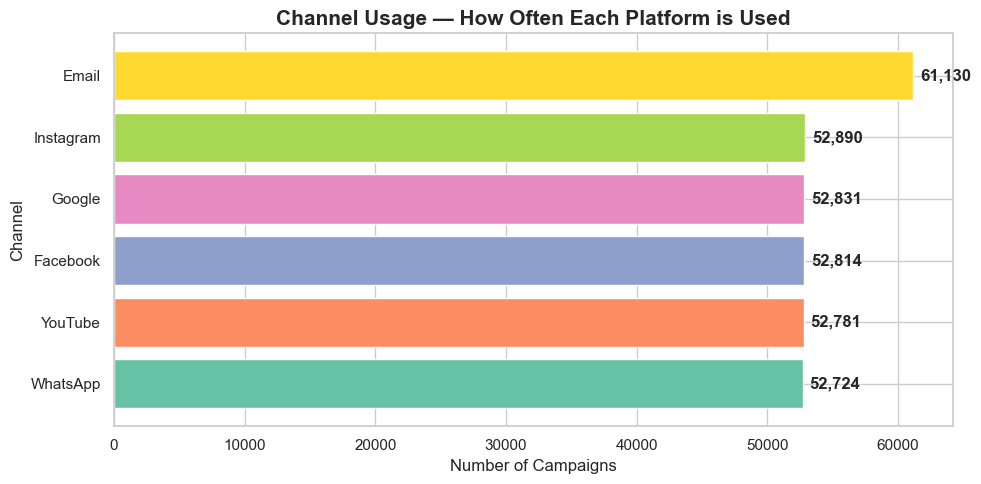


Channel Usage:
Email        61130
Instagram    52890
Google       52831
Facebook     52814
YouTube      52781
WhatsApp     52724
dtype: int64


In [55]:
fig, ax = plt.subplots(figsize=(10, 5))

channel_cols = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']
channel_usage = combined_data[channel_cols].sum().sort_values()

ax.barh(channel_usage.index,
        channel_usage.values,
        color=sns.color_palette('Set2', len(channel_usage)))

ax.set_title('Channel Usage — How Often Each Platform is Used',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Campaigns')
ax.set_ylabel('Channel')

for i, v in enumerate(channel_usage.values):
    ax.text(v * 1.01, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nChannel Usage:")
print(channel_usage.sort_values(ascending=False))

### Revenue per Channel 

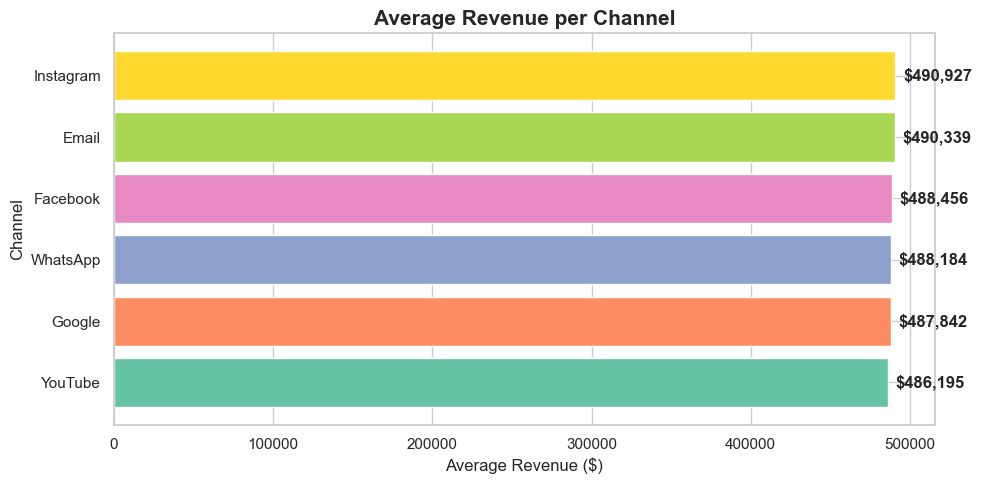


Average Revenue per Channel:
Instagram    $490,927
Email        $490,339
Facebook     $488,456
WhatsApp     $488,184
Google       $487,842
YouTube      $486,195
dtype: str


In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

channel_revenue = {}
for ch in channel_cols:
    # Filter rows where this channel was used (=1) and sum revenue
    channel_revenue[ch] = combined_data[combined_data[ch] == 1]['Revenue'].mean()

channel_revenue = pd.Series(channel_revenue).sort_values()

ax.barh(channel_revenue.index,
        channel_revenue.values,
        color=sns.color_palette('Set2', len(channel_revenue)))

ax.set_title('Average Revenue per Channel',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Average Revenue ($)')
ax.set_ylabel('Channel')

for i, v in enumerate(channel_revenue.values):
    ax.text(v * 1.01, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Revenue per Channel:")
print(channel_revenue.sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

### Each Brand's Spend per Month_Name

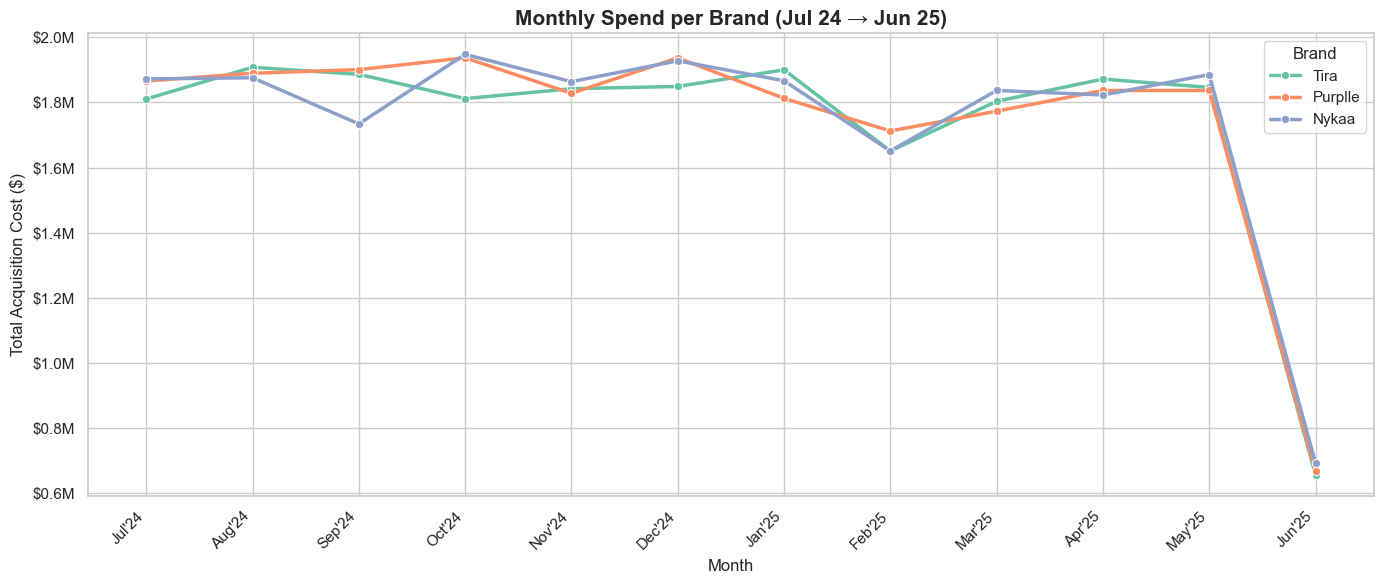


Monthly Spend per Brand ($ Millions):
Brand       Nykaa  Purplle  Tira  Total
Month_Name                             
Dec'24       1.93     1.94  1.85   5.71
Oct'24       1.95     1.94  1.81   5.70
Aug'24       1.88     1.89  1.91   5.67
Jan'25       1.87     1.81  1.90   5.58
May'25       1.89     1.84  1.85   5.57
Jul'24       1.87     1.87  1.81   5.55
Nov'24       1.86     1.83  1.84   5.53
Apr'25       1.82     1.84  1.87   5.53
Sep'24       1.73     1.90  1.89   5.52
Mar'25       1.84     1.77  1.80   5.41
Feb'25       1.65     1.71  1.65   5.01
Jun'25       0.69     0.67  0.66   2.02


In [57]:
fig, ax = plt.subplots(figsize=(14, 6))

brand_monthly_spend = combined_data.groupby(
    ['Month_Name', 'Brand'])['Acquisition_Cost'].sum().reset_index()

month_order = ["Jul'24","Aug'24","Sep'24","Oct'24","Nov'24","Dec'24",
               "Jan'25","Feb'25","Mar'25","Apr'25","May'25","Jun'25"]

brand_monthly_spend['Month_Name'] = pd.Categorical(
    brand_monthly_spend['Month_Name'],
    categories=month_order,
    ordered=True)

brand_monthly_spend = brand_monthly_spend.sort_values('Month_Name')

sns.lineplot(data=brand_monthly_spend,
             x='Month_Name',
             y='Acquisition_Cost',
             hue='Brand',
             palette='Set2',
             linewidth=2.5,
             marker='o',
             ax=ax)

ax.set_title('Monthly Spend per Brand (Jul 24 → Jun 25)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Acquisition Cost ($)')

# ← fix: use ax.tick_params instead of set_xticklabels
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order, rotation=45, ha='right')

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax.legend(title='Brand')
plt.tight_layout()
plt.show()

print("\nMonthly Spend per Brand ($ Millions):")
pivot = brand_monthly_spend.pivot(index='Month_Name', 
                                   columns='Brand', 
                                   values='Acquisition_Cost')

# Add Total column
pivot['Total'] = pivot.sum(axis=1)

# Sort by Total highest to lowest
pivot = pivot.sort_values('Total', ascending=False)

# Display in millions
print((pivot/1e6).round(2))

## Finding 
according to this chart june as lowes as it is the holiday month and costomatic use is les  and christmas mounts  december is higest  as it has christmas and nuwear in end 

## Each Brand's Spend per Channel

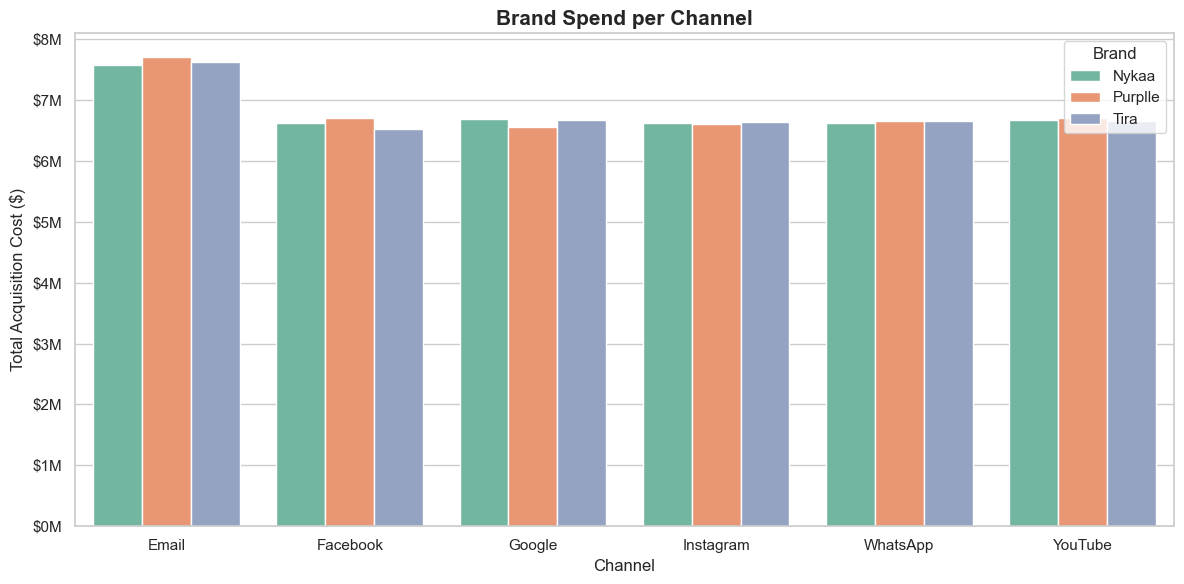


Brand Spend per Channel ($ Millions):
Brand      Nykaa  Purplle  Tira
Channel                        
Email       7.57     7.71  7.62
Facebook    6.62     6.70  6.52
Google      6.69     6.56  6.67
Instagram   6.63     6.60  6.64
WhatsApp    6.63     6.65  6.65
YouTube     6.68     6.70  6.65


In [58]:
fig, ax = plt.subplots(figsize=(12, 6))

channel_cols = ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']

# For each channel, filter rows where channel=1, group by Brand, sum cost
records = []
for ch in channel_cols:
    temp = combined_data[combined_data[ch] == 1].groupby('Brand')['Acquisition_Cost'].sum()
    for brand, val in temp.items():
        records.append({'Channel': ch, 'Brand': brand, 'Spend': val})

channel_brand_spend = pd.DataFrame(records)

sns.barplot(data=channel_brand_spend,
            x='Channel',
            y='Spend',
            hue='Brand',
            palette='Set2',
            ax=ax)

ax.set_title('Brand Spend per Channel',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Total Acquisition Cost ($)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.legend(title='Brand')

plt.tight_layout()
plt.show()

print("\nBrand Spend per Channel ($ Millions):")
pivot2 = channel_brand_spend.pivot_table(index='Channel', 
                                          columns='Brand', 
                                          values='Spend')
print((pivot2/1e6).round(2))

# finding 
Brand spend most of the amount on emails my suggestion should be focus on Youtube and instarahram as it covers may ppl intrested to costmatics 

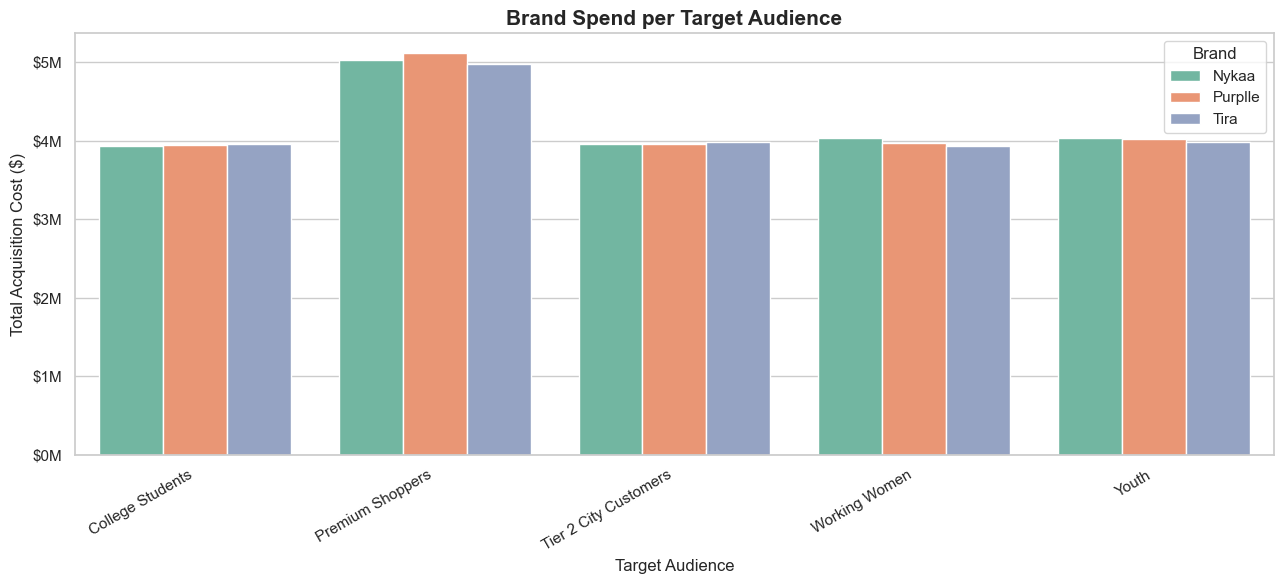


Brand Spend per Target Audience ($ Millions):
Brand                  Nykaa  Purplle  Tira  Total
Target_Audience                                   
Premium Shoppers        5.03     5.11  4.98  15.12
Youth                   4.03     4.02  3.98  12.02
Working Women           4.03     3.97  3.93  11.94
Tier 2 City Customers   3.96     3.95  3.99  11.89
College Students        3.93     3.94  3.96  11.83


In [59]:
fig, ax = plt.subplots(figsize=(13, 6))

brand_audience_spend = combined_data.groupby(
    ['Target_Audience', 'Brand'])['Acquisition_Cost'].sum().reset_index()

sns.barplot(data=brand_audience_spend,
            x='Target_Audience',
            y='Acquisition_Cost',
            hue='Brand',
            palette='Set2',
            ax=ax)

ax.set_title('Brand Spend per Target Audience',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Target Audience')
ax.set_ylabel('Total Acquisition Cost ($)')

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# ← Fix: use plt.xticks() instead of ax.set_xticklabels()
plt.xticks(rotation=30, ha='right')

ax.legend(title='Brand')
plt.tight_layout()
plt.show()

print("\nBrand Spend per Target Audience ($ Millions):")
pivot3 = brand_audience_spend.pivot_table(
    index='Target_Audience',
    columns='Brand',
    values='Acquisition_Cost')
pivot3['Total'] = pivot3.sum(axis=1)
pivot3 = pivot3.sort_values('Total', ascending=False)
print((pivot3/1e6).round(2))


# findings 
Brand focus more om premier  shopers , i would suggested to alos focus on working womens and college student with offeres and rewards that can be used in brad for next sghopping  so they will stay in loop 

 ### Time Trends

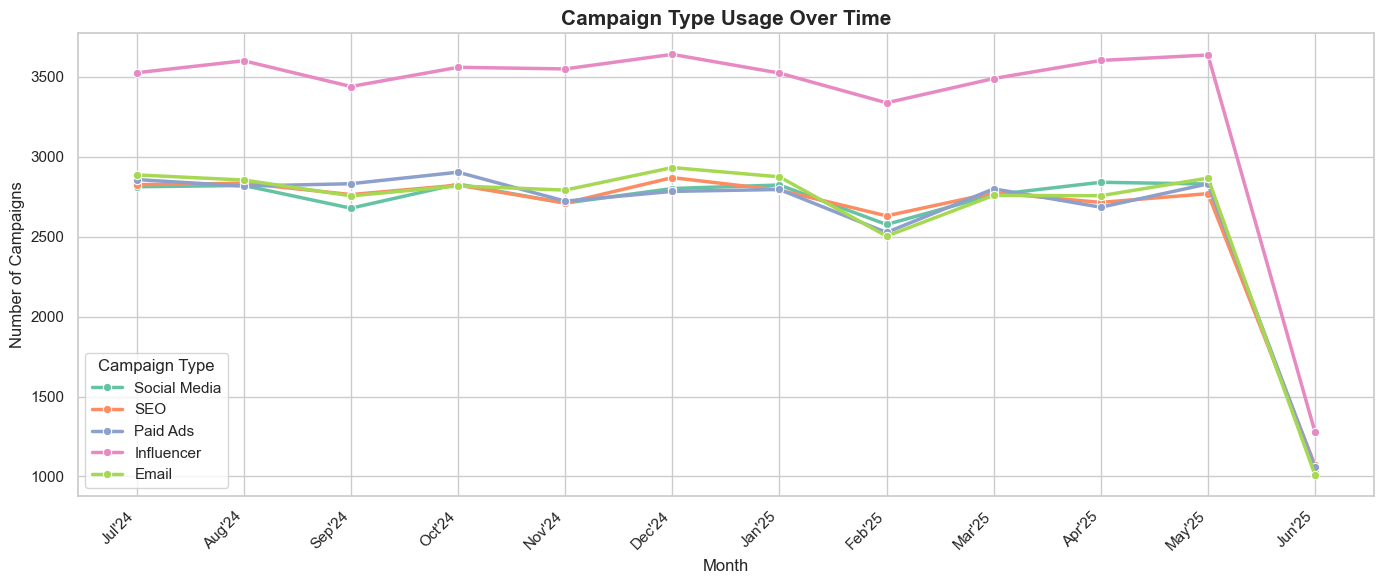

In [60]:
fig, ax = plt.subplots(figsize=(14, 6))

monthly_campaign = combined_data.groupby(
    ['Month_Name', 'Campaign_Type']).size().reset_index(name='Count')

monthly_campaign['Month_Name'] = pd.Categorical(
    monthly_campaign['Month_Name'],
    categories=month_order,
    ordered=True)

monthly_campaign = monthly_campaign.sort_values('Month_Name')

sns.lineplot(data=monthly_campaign,
             x='Month_Name',
             y='Count',
             hue='Campaign_Type',
             palette='Set2',
             linewidth=2.5,
             marker='o',
             ax=ax)

ax.set_title('Campaign Type Usage Over Time',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Campaigns')

plt.xticks(rotation=45, ha='right')
ax.legend(title='Campaign Type')
plt.tight_layout()
plt.show()

In [61]:
combined_data.head(2)

,Brand,Campaign_Type,Target_Audience,Duration,Email,Facebook,Google,Instagram,WhatsApp,YouTube,...,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Language,Engagement_Score,Customer_Segment,Month_Name
0,Nykaa,Social Media,College Students,21.0,0,0,0,0,1,1,...,6156.0,3616.0,2355.0,1867515.0,376.83056,4954.85,Hindi,20.98,College Students,Apr'25
1,Nykaa,Paid Ads,Tier 2 City Customers,18.0,0,0,0,0,0,1,...,3321.0,1971.0,1357.0,1046247.0,180.83000,5784.80,Hindi,7.24,College Students,Apr'25


### Fixing the outliers 


In [62]:
# First let's SEE the outliers in our key columns
numerical_cols = ['Revenue', 'Updated_ROI', 'Impressions', 
                  'Clicks', 'Leads', 'Conversions', 
                  'Acquisition_Cost', 'Engagement_Score', 'Duration']

print("═══ OUTLIER ANALYSIS ═══\n")
for col in numerical_cols:
    Q1  = combined_data[col].quantile(0.25)
    Q3  = combined_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    
    outliers = combined_data[
        (combined_data[col] < lower) | 
        (combined_data[col] > upper)
    ]
    
    pct = len(outliers) / len(combined_data) * 100
    
    print(f"{col:20} → outliers: {len(outliers):6,} ({pct:.1f}%)"
          f"  |  min: {combined_data[col].min():.1f}"
          f"  max: {combined_data[col].max():.1f}"
          f"  upper fence: {upper:.1f}")

═══ OUTLIER ANALYSIS ═══

Revenue              → outliers:  9,415 (5.6%)  |  min: 0.0  max: 4579910.0  upper fence: 1416888.0
Updated_ROI          → outliers: 19,653 (11.8%)  |  min: -1.0  max: 494114.4  upper fence: 12828.7
Impressions          → outliers:      0 (0.0%)  |  min: 10001.0  max: 100000.0  upper fence: 140393.0
Clicks               → outliers:  1,885 (1.1%)  |  min: 202.0  max: 14944.0  upper fence: 12997.5
Leads                → outliers:  6,184 (3.7%)  |  min: 48.0  max: 8876.0  upper fence: 5099.0
Conversions          → outliers:  8,079 (4.8%)  |  min: 17.0  max: 6686.0  upper fence: 2767.0
Acquisition_Cost     → outliers: 15,144 (9.1%)  |  min: 8.2  max: 15473.2  upper fence: 860.7
Engagement_Score     → outliers:      0 (0.0%)  |  min: 2.6  max: 31.0  upper fence: 33.4
Duration             → outliers:      0 (0.0%)  |  min: 5.0  max: 30.0  upper fence: 43.5


In [63]:
# We use PERCENTILE CAPPING (Winsorization)
# Cap at 1st percentile (lower) and 99th percentile (upper)
# Values outside this range get pulled to the boundary

cols_to_cap = ['Revenue', 'Updated_ROI', 'Clicks', 
               'Leads', 'Conversions', 'Acquisition_Cost']

print("═══ CAPPING OUTLIERS ═══\n")

for col in cols_to_cap:
    # Calculate 1st and 99th percentile
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    
    # Count outliers before
    before = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    # Cap the values
    # clip() → values below lower_cap → become lower_cap
    #          values above upper_cap → become upper_cap
    #          values in between      → unchanged ✅
    combined_data[col] = combined_data[col].clip(
        lower=lower_cap, 
        upper=upper_cap
    )
    
    # Count outliers after
    after = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    print(f"✅ {col:20}")
    print(f"   Lower cap : {lower_cap:.2f}")
    print(f"   Upper cap : {upper_cap:.2f}")
    print(f"   Before    : {before:,} outliers")
    print(f"   After     : {after:,} outliers")
    print(f"   New range : {combined_data[col].min():.2f} → {combined_data[col].max():.2f}")
    print()

═══ CAPPING OUTLIERS ═══

✅ Revenue             
   Lower cap : 0.00
   Upper cap : 2302558.72
   Before    : 1,667 outliers
   After     : 0 outliers
   New range : 0.00 → 2302558.72

✅ Updated_ROI         
   Lower cap : -1.00
   Upper cap : 65332.48
   Before    : 1,667 outliers
   After     : 0 outliers
   New range : -1.00 → 65332.48

✅ Clicks              
   Lower cap : 459.00
   Upper cap : 13107.72
   Before    : 3,327 outliers
   After     : 0 outliers
   New range : 459.00 → 13107.72

✅ Leads               
   Lower cap : 156.00
   Upper cap : 6358.36
   Before    : 3,330 outliers
   After     : 0 outliers
   New range : 156.00 → 6358.36

✅ Conversions         
   Lower cap : 76.00
   Upper cap : 3946.36
   Before    : 3,333 outliers
   After     : 0 outliers
   New range : 76.00 → 3946.36

✅ Acquisition_Cost    
   Lower cap : 25.25
   Upper cap : 2558.92
   Before    : 3,332 outliers
   After     : 0 outliers
   New range : 25.25 → 2558.92



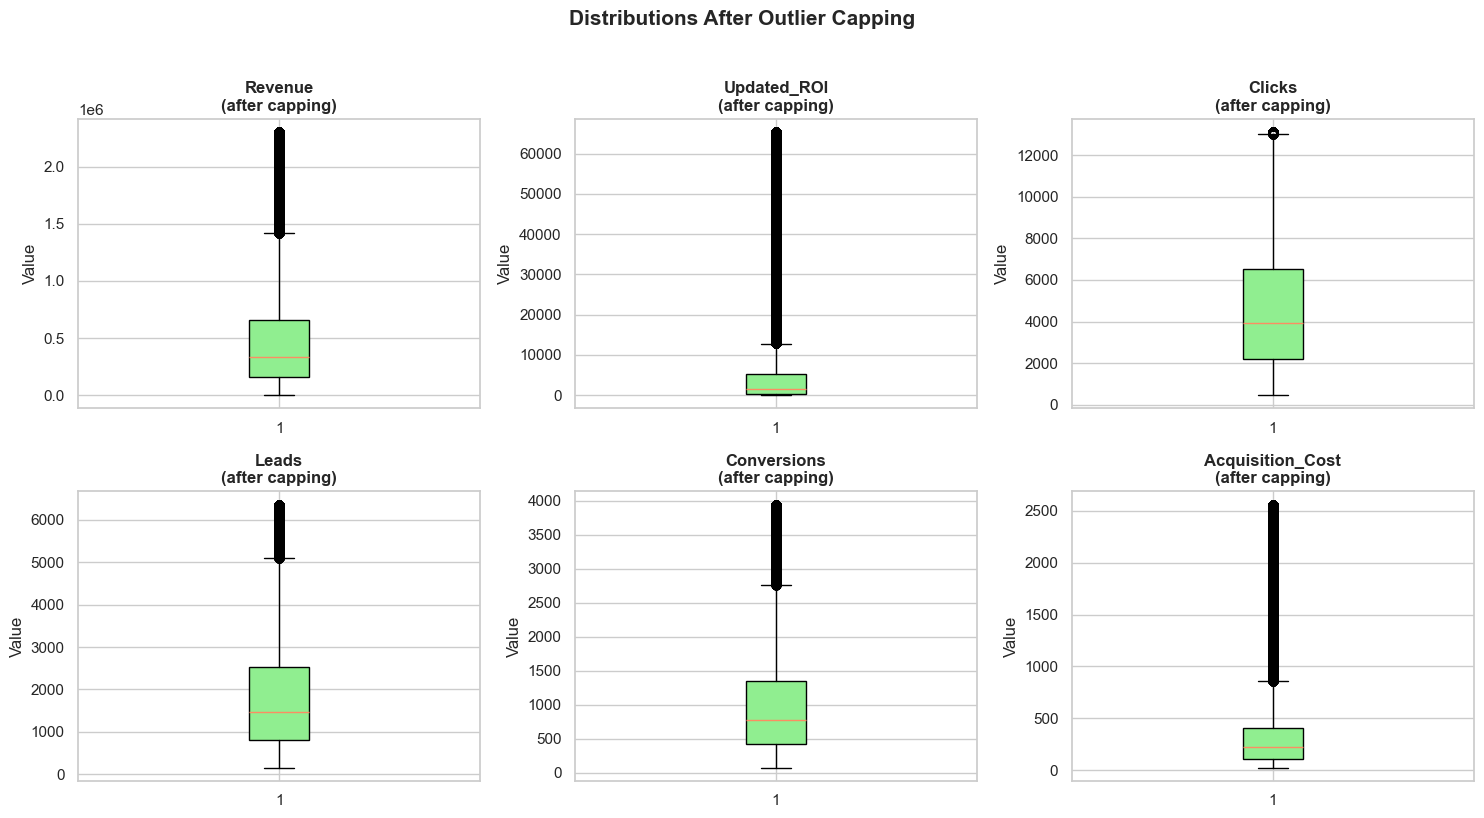


═══ FINAL STATS AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.00  166665.00  166665.00    166665.00   
mean    483674.51      5504.53    4641.54    1847.10      1010.75   
std     467066.19     10610.48    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       342.72    2185.00     809.00       417.00   
50%     335780.00      1468.71    3908.00    1476.00       775.00   
75%     659505.00      5337.12    6510.00    2525.00      1357.00   
max    2302558.72     65332.48   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         166665.00  
mean             364.52  
std              429.45  
min               25.25  
25%              111.10  
50%              222.92  
75%              410.92  
max             2558.92  


In [64]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(combined_data[col], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{col}\n(after capping)', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Distributions After Outlier Capping', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n═══ FINAL STATS AFTER CAPPING ═══")
print(combined_data[cols_to_cap].describe().round(2))

## before caping and aftrer  caping 

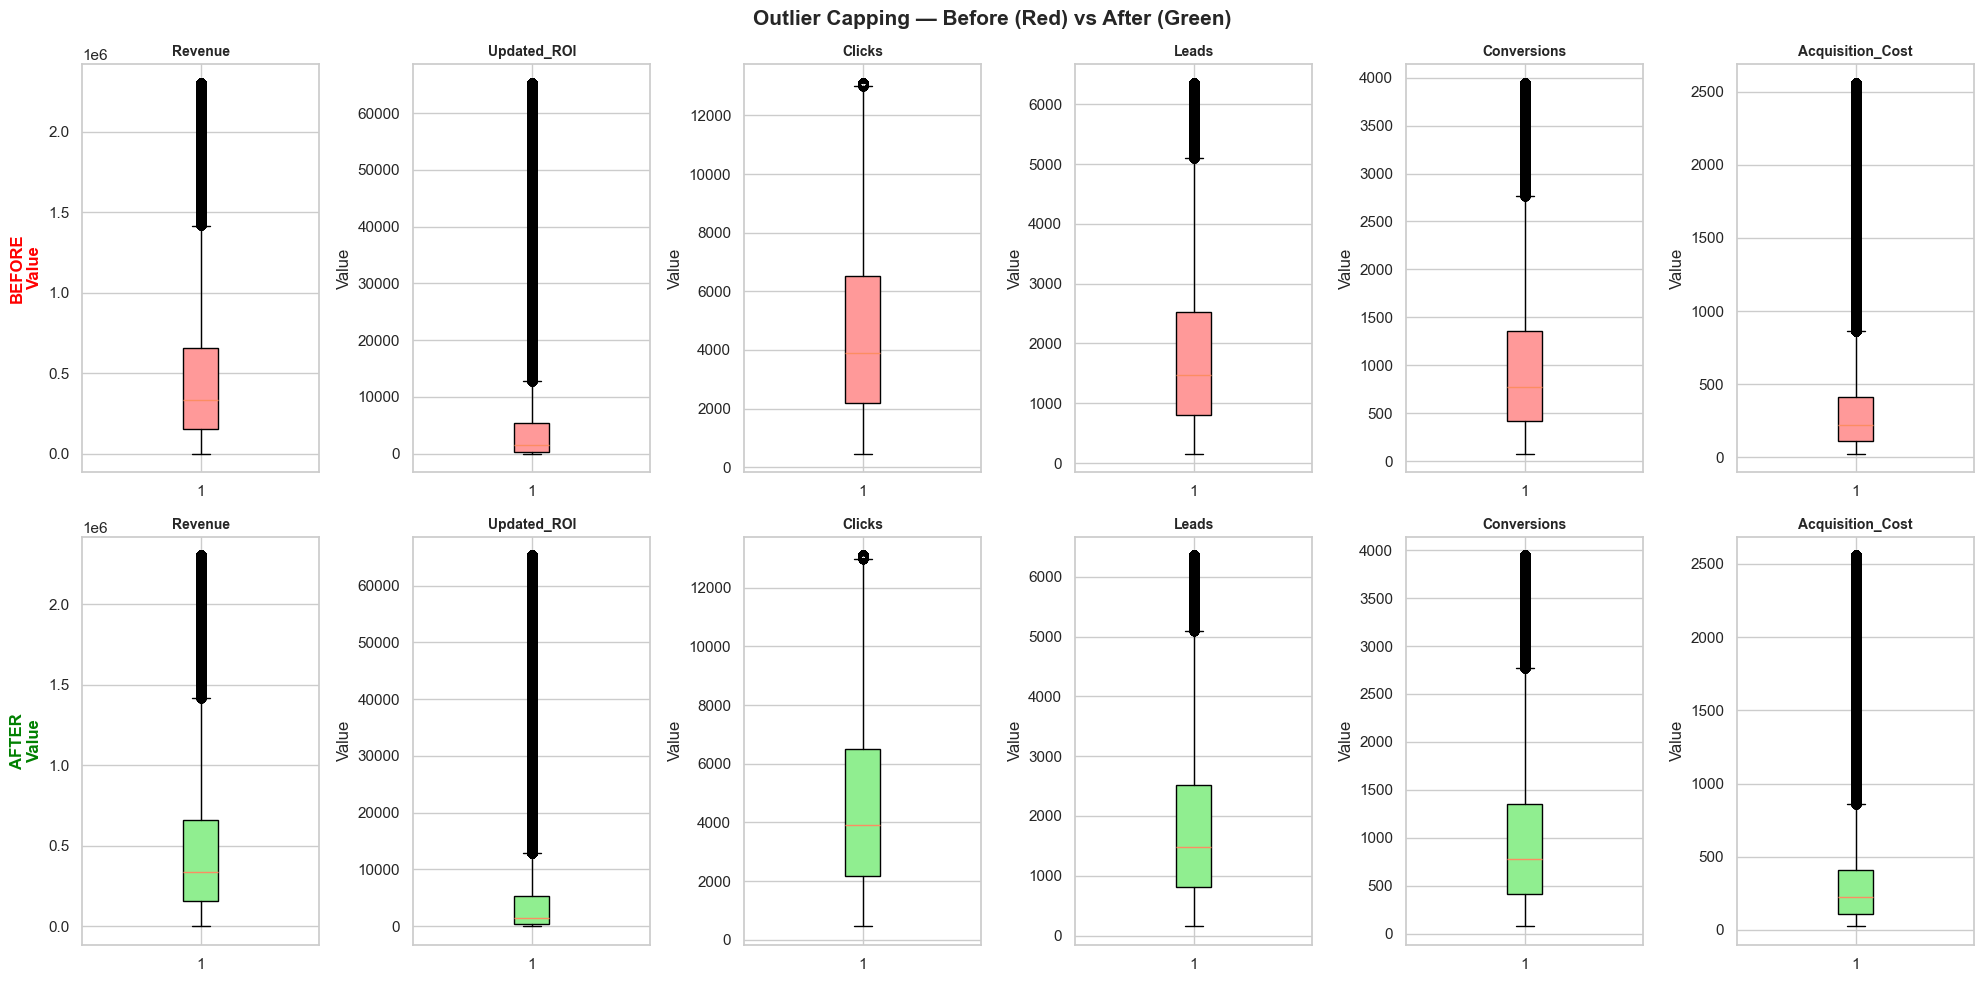

═══ BEFORE CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.00  166665.00  166665.00    166665.00   
mean    483674.51      5504.53    4641.54    1847.10      1010.75   
std     467066.19     10610.48    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       342.72    2185.00     809.00       417.00   
50%     335780.00      1468.71    3908.00    1476.00       775.00   
75%     659505.00      5337.12    6510.00    2525.00      1357.00   
max    2302558.72     65332.48   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         166665.00  
mean             364.52  
std              429.45  
min               25.25  
25%              111.10  
50%              222.92  
75%              410.92  
max             2558.92  

═══ AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.0

In [65]:
# Store BEFORE stats first (run this BEFORE capping)
before_data = combined_data[cols_to_cap].copy()

# ── NOW CAP ──────────────────────────────────────────────
for col in cols_to_cap:
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    combined_data[col] = combined_data[col].clip(lower=lower_cap, upper=upper_cap)

after_data = combined_data[cols_to_cap].copy()

# ── PLOT BEFORE vs AFTER ─────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(20, 10))

for i, col in enumerate(cols_to_cap):
    
    # Top row → BEFORE
    axes[0, i].boxplot(before_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#ff9999'))  # red = before
    axes[0, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Value')
    
    # Bottom row → AFTER
    axes[1, i].boxplot(after_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#90ee90'))  # green = after
    axes[1, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[1, i].set_ylabel('Value')

# Row labels
axes[0, 0].set_ylabel('BEFORE\nValue', fontweight='bold', color='red')
axes[1, 0].set_ylabel('AFTER\nValue', fontweight='bold', color='green')

plt.suptitle('Outlier Capping — Before (Red) vs After (Green)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STATS COMPARISON ─────────────────────────────────────
print("═══ BEFORE CAPPING ═══")
print(before_data.describe().round(2))

print("\n═══ AFTER CAPPING ═══")
print(after_data.describe().round(2))

print("\n═══ WHAT CHANGED ═══")
for col in cols_to_cap:
    print(f"\n{col}:")
    print(f"  Max before → {before_data[col].max():.2f}")
    print(f"  Max after  → {after_data[col].max():.2f}")
    print(f"  Min before → {before_data[col].min():.2f}")
    print(f"  Min after  → {after_data[col].min():.2f}")

# encoding 
changing words to binary 


In [66]:
# See current categorical columns
cat_cols = combined_data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:")
for col in cat_cols:
    print(f"  {col:25} → {combined_data[col].nunique()} unique values: {combined_data[col].unique().tolist()}")

Categorical columns to encode:
  Brand                     → 3 unique values: ['Nykaa', 'Purplle', 'Tira']
  Campaign_Type             → 5 unique values: ['Social Media', 'Paid Ads', 'Influencer', 'Email', 'SEO']
  Target_Audience           → 5 unique values: ['College Students', 'Tier 2 City Customers', 'Youth', 'Working Women', 'Premium Shoppers']
  Language                  → 5 unique values: ['Hindi', 'English', 'Native', 'Tamil', 'Bengali']
  Customer_Segment          → 6 unique values: ['College Students', 'Basic Plan', 'Tier 2 City Customers', 'Premium Shoppers', 'Youth', 'Working Women']
  Month_Name                → 12 unique values: ["Apr'25", "Jan'25", "Jun'25", "Dec'24", "Sep'24", "May'25", "Mar'25", "Oct'24", "Jul'24", "Feb'25", "Aug'24", "Nov'24"]


C:\Users\Saroon\AppData\Local\Temp\ipykernel_16596\1079082900.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = combined_data.select_dtypes(include='object').columns.tolist()


In [67]:
combined_data['Profit_Flag'] = (combined_data['Updated_ROI'] > 0).astype(int)

print("✅ Profit_Flag created!")
print(combined_data['Profit_Flag'].value_counts())
print(f"\nProfit % : {combined_data['Profit_Flag'].mean()*100:.1f}%")
print(f"Loss   % : {(1-combined_data['Profit_Flag'].mean())*100:.1f}%")

✅ Profit_Flag created!
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64

Profit % : 95.0%
Loss   % : 5.0%


In [68]:
# Re-encode with drop_first=False → keeps ALL 3 brands
encode_cols = ['Brand', 'Campaign_Type', 'Target_Audience', 
               'Language', 'Customer_Segment']

combined_encoded = pd.get_dummies(combined_data, 
                                   columns=encode_cols,
                                   drop_first=False)  

print("✅ Encoding done!")
print(f"Shape before : {combined_data.shape}")
print(f"Shape after  : {combined_encoded.shape}")

✅ Encoding done!
Shape before : (166665, 22)
Shape after  : (166665, 41)


In [69]:
text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()
print("Text columns remaining:", text_cols)  # must be []

print("\nData types:")
print(combined_encoded.dtypes.value_counts())

print("\nShape:", combined_encoded.shape)
print("\nSample:")
print(combined_encoded.head(3))

Text columns remaining: ['Month_Name']

Data types:
bool       24
float64     9
int64       7
str         1
Name: count, dtype: int64

Shape: (166665, 41)

Sample:
   Duration  Email  Facebook  Google  Instagram  WhatsApp  YouTube  \
0      21.0      0         0       0          0         1        1   
1      18.0      0         0       0          0         0        1   
2      23.0      0         0       1          0         1        1   

   Impressions  Clicks   Leads  ...  Language_English  Language_Hindi  \
0      57804.0  6156.0  3616.0  ...             False            True   
1      91801.0  3321.0  1971.0  ...             False            True   
2      15536.0  2182.0   952.0  ...              True           False   

   Language_Native  Language_Tamil  Customer_Segment_Basic Plan  \
0            False           False                        False   
1            False           False                        False   
2            False           False                        Fal

C:\Users\Saroon\AppData\Local\Temp\ipykernel_16596\2543108577.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()


### Droped momths as it is not required 
anymore  and converting  bool columns to int. 

In [70]:
# Fix 1 — Drop Month_Name
combined_encoded.drop(columns=['Month_Name'], inplace=True)

# Fix 2 — Convert bool columns to int (True→1, False→0)
# ML models prefer int over bool
bool_cols = combined_encoded.select_dtypes(include='bool').columns.tolist()
combined_encoded[bool_cols] = combined_encoded[bool_cols].astype(int)

# Verify
text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()
print("Text columns remaining:", text_cols)   # must be []

print("\nData types:")
print(combined_encoded.dtypes.value_counts())

print("\nShape:", combined_encoded.shape)

print("\nSample:")
print(combined_encoded.head(3))

Text columns remaining: []

Data types:
int64      31
float64     9
Name: count, dtype: int64

Shape: (166665, 40)

Sample:
   Duration  Email  Facebook  Google  Instagram  WhatsApp  YouTube  \
0      21.0      0         0       0          0         1        1   
1      18.0      0         0       0          0         0        1   
2      23.0      0         0       1          0         1        1   

   Impressions  Clicks   Leads  ...  Language_English  Language_Hindi  \
0      57804.0  6156.0  3616.0  ...                 0               1   
1      91801.0  3321.0  1971.0  ...                 0               1   
2      15536.0  2182.0   952.0  ...                 1               0   

   Language_Native  Language_Tamil  Customer_Segment_Basic Plan  \
0                0               0                            0   
1                0               0                            0   
2                0               0                            0   

   Customer_Segment_College Stude

In [71]:
combined_data.head(2)

,Brand,Campaign_Type,Target_Audience,Duration,Email,Facebook,Google,Instagram,WhatsApp,YouTube,...,Leads,Conversions,Revenue,Acquisition_Cost,Updated_ROI,Language,Engagement_Score,Customer_Segment,Month_Name,Profit_Flag
0,Nykaa,Social Media,College Students,21.0,0,0,0,0,1,1,...,3616.0,2355.0,1867515.0,376.83056,4954.85,Hindi,20.98,College Students,Apr'25,1
1,Nykaa,Paid Ads,Tier 2 City Customers,18.0,0,0,0,0,0,1,...,1971.0,1357.0,1046247.0,180.83000,5784.80,Hindi,7.24,College Students,Apr'25,1


In [72]:
combined_encoded

,Duration,Email,Facebook,Google,Instagram,WhatsApp,YouTube,Impressions,Clicks,Leads,...,Language_English,Language_Hindi,Language_Native,Language_Tamil,Customer_Segment_Basic Plan,Customer_Segment_College Students,Customer_Segment_Premium Shoppers,Customer_Segment_Tier 2 City Customers,Customer_Segment_Working Women,Customer_Segment_Youth
0,21.0,0,0,0,0,1,1,57804.0,6156.0,3616.0,...,0,1,0,0,0,1,0,0,0,0
1,18.0,0,0,0,0,0,1,91801.0,3321.0,1971.0,...,0,1,0,0,0,1,0,0,0,0
2,23.0,0,0,1,0,1,1,15536.0,2182.0,952.0,...,1,0,0,0,0,1,0,0,0,0
3,18.0,0,1,0,1,0,1,88114.0,8413.0,2231.0,...,0,1,0,0,1,0,0,0,0,0
4,10.0,0,1,0,1,0,0,96871.0,3743.0,2060.0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,11.0,1,0,0,1,0,1,55113.0,3799.0,1476.0,...,0,0,0,0,0,0,0,0,0,1
166661,20.0,0,0,1,1,0,0,54886.0,1578.0,634.0,...,1,0,0,0,0,0,0,0,1,0
166662,13.0,0,1,0,1,0,0,97954.0,11480.0,4567.0,...,0,0,1,0,0,0,1,0,0,0
166663,22.0,1,0,1,0,0,0,11669.0,3908.0,156.0,...,1,0,0,0,0,0,0,0,1,0


In [73]:
# Check Brand columns specifically
brand_cols = [c for c in combined_encoded.columns if 'Brand' in c]
print("Brand columns:", brand_cols)

print("\nAll columns:")
for col in combined_encoded.columns.tolist():
    print(f"  {col}")

print("\nShape:", combined_encoded.shape)

Brand columns: ['Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira']

All columns:
  Duration
  Email
  Facebook
  Google
  Instagram
  WhatsApp
  YouTube
  Impressions
  Clicks
  Leads
  Conversions
  Revenue
  Acquisition_Cost
  Updated_ROI
  Engagement_Score
  Profit_Flag
  Brand_Nykaa
  Brand_Purplle
  Brand_Tira
  Campaign_Type_Email
  Campaign_Type_Influencer
  Campaign_Type_Paid Ads
  Campaign_Type_SEO
  Campaign_Type_Social Media
  Target_Audience_College Students
  Target_Audience_Premium Shoppers
  Target_Audience_Tier 2 City Customers
  Target_Audience_Working Women
  Target_Audience_Youth
  Language_Bengali
  Language_English
  Language_Hindi
  Language_Native
  Language_Tamil
  Customer_Segment_Basic Plan
  Customer_Segment_College Students
  Customer_Segment_Premium Shoppers
  Customer_Segment_Tier 2 City Customers
  Customer_Segment_Working Women
  Customer_Segment_Youth

Shape: (166665, 40)


### preparing  slpiting X\Y  for Regeration and classification  

In [74]:
# Drop both target columns from X
X = combined_encoded.drop(columns=['Revenue', 'Profit_Flag'])

# Regression target
y_reg = combined_encoded['Revenue']

# Classification target
y_clf = combined_encoded['Profit_Flag']

print("X shape :", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)
print("\nX columns:", X.columns.tolist())
print("\ny_reg sample:", y_reg.head(3).values)
print("y_clf sample:", y_clf.head(3).values)

X shape : (166665, 38)
y_reg shape: (166665,)
y_clf shape: (166665,)

X columns: ['Duration', 'Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Acquisition_Cost', 'Updated_ROI', 'Engagement_Score', 'Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira', 'Campaign_Type_Email', 'Campaign_Type_Influencer', 'Campaign_Type_Paid Ads', 'Campaign_Type_SEO', 'Campaign_Type_Social Media', 'Target_Audience_College Students', 'Target_Audience_Premium Shoppers', 'Target_Audience_Tier 2 City Customers', 'Target_Audience_Working Women', 'Target_Audience_Youth', 'Language_Bengali', 'Language_English', 'Language_Hindi', 'Language_Native', 'Language_Tamil', 'Customer_Segment_Basic Plan', 'Customer_Segment_College Students', 'Customer_Segment_Premium Shoppers', 'Customer_Segment_Tier 2 City Customers', 'Customer_Segment_Working Women', 'Customer_Segment_Youth']

y_reg sample: [1867515. 1046247.  197055.]
y_clf sample: [1 1 1]


## X and y for Regression

In [75]:
# ── X = all columns except targets ────────────────────
X_reg = combined_encoded.drop(columns=[
    'Revenue',      # this is y_reg (target)
    'Profit_Flag',  # this is y_clf (classification target)
])

# ── y = Revenue ────────────────────────────────────────
y_reg = combined_encoded['Revenue']

print(f"✅ X_reg shape : {X_reg.shape}")
print(f"✅ y_reg shape : {y_reg.shape}")
print(f"\nX columns ({len(X_reg.columns)}):")
for col in X_reg.columns:
    print(f"  {col}")
print(f"\ny_reg stats:")
print(f"  Min  : ₹{y_reg.min():,.0f}")
print(f"  Max  : ₹{y_reg.max():,.0f}")
print(f"  Mean : ₹{y_reg.mean():,.0f}")

✅ X_reg shape : (166665, 38)
✅ y_reg shape : (166665,)

X columns (38):
  Duration
  Email
  Facebook
  Google
  Instagram
  WhatsApp
  YouTube
  Impressions
  Clicks
  Leads
  Conversions
  Acquisition_Cost
  Updated_ROI
  Engagement_Score
  Brand_Nykaa
  Brand_Purplle
  Brand_Tira
  Campaign_Type_Email
  Campaign_Type_Influencer
  Campaign_Type_Paid Ads
  Campaign_Type_SEO
  Campaign_Type_Social Media
  Target_Audience_College Students
  Target_Audience_Premium Shoppers
  Target_Audience_Tier 2 City Customers
  Target_Audience_Working Women
  Target_Audience_Youth
  Language_Bengali
  Language_English
  Language_Hindi
  Language_Native
  Language_Tamil
  Customer_Segment_Basic Plan
  Customer_Segment_College Students
  Customer_Segment_Premium Shoppers
  Customer_Segment_Tier 2 City Customers
  Customer_Segment_Working Women
  Customer_Segment_Youth

y_reg stats:
  Min  : ₹0
  Max  : ₹2,302,558
  Mean : ₹483,675


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size    = 0.2,
    random_state = 42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train : {X_train.shape}  (80%)")
print(f"✅ Test  : {X_test.shape}   (20%)")
print(f"✅ Mean  : {X_train_sc.mean():.6f}")
print(f"✅ Std   : {X_train_sc.std():.6f}")

✅ Train : (133332, 38)  (80%)
✅ Test  : (33333, 38)   (20%)
✅ Mean  : -0.000000
✅ Std   : 1.000000


## Running all models 


In [77]:
results = {}

def add_result(name, model, Xtr, Xte):
    yp    = model.predict(Xte)
    yp_tr = model.predict(Xtr)
    results[name] = {
        'r2'      : r2_score(y_test, yp),
        'r2_train': r2_score(y_train, yp_tr),
        'rmse'    : np.sqrt(mean_squared_error(y_test, yp)),
        'mae'     : mean_absolute_error(y_test, yp),
        'y_pred'  : yp
    }
    gap = abs(results[name]['r2_train'] - results[name]['r2'])
    print(f"✅ {name:<15} R²: {results[name]['r2']*100:.2f}%  "
          f"Gap: {gap:.4f}  RMSE: ₹{results[name]['rmse']:,.0f}")

# 1. Linear (scaled)
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
add_result('Linear', lr, X_train_sc, X_test_sc)

# 2. Ridge (scaled)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
add_result('Ridge', ridge, X_train_sc, X_test_sc)

# 3. Lasso (scaled)
lasso = Lasso(alpha=1.0, max_iter=10000)  # ← added max_iter
lasso.fit(X_train_sc, y_train)
add_result('Lasso', lasso, X_train_sc, X_test_sc)

# 4. Decision Tree (no scaling)
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
add_result('Decision Tree', dt, X_train, X_test)

# 5. Random Forest (no scaling)
rf = RandomForestRegressor(random_state=42)  
print("Training Random Forest...")
rf.fit(X_train, y_train)
add_result('Random Forest', rf, X_train, X_test)

# 6. XGBoost (no scaling)
xgb = XGBRegressor(random_state=42, verbosity=0)  # ← added verbosity
print("Training XGBoost...")
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)], verbose=False)
add_result('XGBoost', xgb, X_train, X_test)

✅ Linear          R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Ridge           R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Lasso           R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Decision Tree   R²: 99.21%  Gap: 0.0079  RMSE: ₹41,483
Training Random Forest...
✅ Random Forest   R²: 99.65%  Gap: 0.0029  RMSE: ₹27,550
Training XGBoost...
✅ XGBoost         R²: 99.20%  Gap: 0.0057  RMSE: ₹41,744


## Saving as pickle file for XGBoost object regression 

In [78]:
# ── Create models folder ───────────────────────────────
model_dir = r'C:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\models'
os.makedirs(model_dir, exist_ok=True)

# ── Pack everything into ONE dictionary ───────────────
regression_package = {
    'model'       : xgb,
    'scaler'      : scaler,
    'features'    : X_reg.columns.tolist(),
    'model_name'  : 'XGBoost Regressor',
    'r2_score'    : results['XGBoost']['r2'],
    'rmse'        : results['XGBoost']['rmse'],
    'mae'         : results['XGBoost']['mae'],
    'gap'         : abs(results['XGBoost']['r2_train'] -
                        results['XGBoost']['r2']),
    'target'      : 'Revenue',
    'trained_on'  : f"{len(X_train):,} rows"
}

# ── Save as ONE file ───────────────────────────────────
save_path = os.path.join(model_dir, 'regression_model.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(regression_package, f)

print(f"✅ Saved: regression_model.pkl")
print(f"\nContents:")
for key, val in regression_package.items():
    if key not in ['model', 'scaler', 'features']:
        print(f"  {key:12} : {val}")
print(f"  {'features':12} : {len(regression_package['features'])} columns")
print(f"  {'model':12} : XGBoost object ✅")
print(f"  {'scaler':12} : StandardScaler object ✅")

✅ Saved: regression_model.pkl

Contents:
  model_name   : XGBoost Regressor
  r2_score     : 0.9919706785419811
  rmse         : 41744.25327853156
  mae          : 12191.25990419828
  gap          : 0.005714014580396554
  target       : Revenue
  trained_on   : 133,332 rows
  features     : 38 columns
  model        : XGBoost object ✅
  scaler       : StandardScaler object ✅


## testing the XGBoost  regression 

In [79]:
# Load and test
with open(save_path, 'rb') as f:
    pkg = pickle.load(f)

loaded_model = pkg['model']
y_pred_check = loaded_model.predict(X_test)
r2_check     = r2_score(y_test, y_pred_check)

print("── Verification ──")
print(f"✅ Loaded model  : {pkg['model_name']}")
print(f"✅ Original R²   : {pkg['r2_score']*100:.2f}%")
print(f"✅ Reloaded R²   : {r2_check*100:.2f}%")
print(f"✅ Match         : {abs(pkg['r2_score'] - r2_check) < 0.0001}")

print("\n── Sample Predictions ──")
print(f"{'Actual':>15}  {'Predicted':>15}  {'Error%':>8}")
for a, p in zip(y_test.values[:5], y_pred_check[:5]):
    err = abs(a-p)/a*100 if a != 0 else 0
    print(f"₹{a:>13,.0f}  ₹{p:>13,.0f}  {err:>7.1f}%")

── Verification ──
✅ Loaded model  : XGBoost Regressor
✅ Original R²   : 99.20%
✅ Reloaded R²   : 99.20%
✅ Match         : True

── Sample Predictions ──
         Actual        Predicted    Error%
₹      338,364  ₹      338,738      0.1%
₹    1,226,298  ₹    1,210,705      1.3%
₹       69,596  ₹       75,589      8.6%
₹      437,138  ₹      420,779      3.7%
₹      756,432  ₹      724,068      4.3%


In [80]:
import subprocess
subprocess.run(['pip', 'install', 'lightgbm'], check=True)
print("✅ LightGBM installed")

✅ LightGBM installed


## spliting X and Y for classificxation 

In [81]:
X_clf = combined_encoded.drop(columns=['Revenue', 'Profit_Flag'])
y_clf = combined_encoded['Profit_Flag']
print(f"X shape : {X_clf.shape}")
print(f"y shape : {y_clf.shape}")
print(f"\nClass distribution:")
print(y_clf.value_counts())
print(f"Profit % : {y_clf.mean()*100:.2f}%")
print(f"Loss   % : {(1-y_clf.mean())*100:.2f}%")
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_clf
)
# Scale (needed for Logistic, KNN, SVM, Naive Bayes)
scaler_c     = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print(f"\n✅ Train : {X_train_c.shape}")
print(f"✅ Test  : {X_test_c.shape}")

X shape : (166665, 38)
y shape : (166665,)

Class distribution:
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64
Profit % : 95.01%
Loss   % : 4.99%

✅ Train : (133332, 38)
✅ Test  : (33333, 38)


In [82]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
import numpy as np
import time

clf_results = {}

def evaluate_clf(name, model, Xtr, Xte, start_time):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    yp_tr   = model.predict(Xtr)
    elapsed = time.time() - start_time

    clf_results[name] = {
        'accuracy'  : accuracy_score(y_test_c, yp),
        'precision' : precision_score(y_test_c, yp,
                                      zero_division=0),
        'recall'    : recall_score(y_test_c, yp),
        'f1'        : f1_score(y_test_c, yp),
        'roc_auc'   : roc_auc_score(y_test_c, yp_prob),
        'train_acc' : accuracy_score(y_train_c, yp_tr),
        'time'      : elapsed,
        'y_pred'    : yp,
        'y_prob'    : yp_prob
    }
    gap = abs(clf_results[name]['train_acc'] -
              clf_results[name]['accuracy'])
    print(f"✅ {name:<25} "
          f"Acc: {clf_results[name]['accuracy']*100:.2f}%  "
          f"F1: {clf_results[name]['f1']*100:.2f}%  "
          f"AUC: {clf_results[name]['roc_auc']:.3f}  "
          f"Gap: {gap:.4f}  "
          f"Time: {elapsed:.1f}s")

print("✅ Helper function ready")

✅ Helper function ready


In [83]:
# ── 1. Logistic Regression ────────────────────────────
print("Training Logistic Regression...")
t = time.time()
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train_c_sc, y_train_c)
evaluate_clf('Logistic Regression', lr_clf,
             X_train_c_sc, X_test_c_sc, t)

# ── 2. Decision Tree ──────────────────────────────────
print("Training Decision Tree...")
t = time.time()
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_c, y_train_c)
evaluate_clf('Decision Tree', dt_clf,
             X_train_c, X_test_c, t)

Training Logistic Regression...
✅ Logistic Regression       Acc: 98.20%  F1: 99.06%  AUC: 0.983  Gap: 0.0004  Time: 0.6s
Training Decision Tree...
✅ Decision Tree             Acc: 100.00%  F1: 100.00%  AUC: 1.000  Gap: 0.0000  Time: 0.3s


##  Logistic Regression Gap: 0.0004 almost zero overfitting  how ?
 Decision Tree             Acc: 100.00%   it has leakege as update ROI  has formula directly determines Profit_Flag  

In [84]:
# ── 3. Random Forest ──────────────────────────────────
print("Training Random Forest...")
t = time.time()
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_c, y_train_c)
evaluate_clf('Random Forest', rf_clf,
             X_train_c, X_test_c, t)

# ── 4. XGBoost ────────────────────────────────────────
print("Training XGBoost...")
t = time.time()
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train_c, y_train_c,
            eval_set=[(X_test_c, y_test_c)],
            verbose=False)
evaluate_clf('XGBoost', xgb_clf,
             X_train_c, X_test_c, t)

Training Random Forest...
✅ Random Forest             Acc: 100.00%  F1: 100.00%  AUC: 1.000  Gap: 0.0000  Time: 16.6s
Training XGBoost...
✅ XGBoost                   Acc: 99.90%  F1: 99.95%  AUC: 1.000  Gap: 0.0010  Time: 1.0s


In [85]:
# ══════════════════════════════════════════════════════
# CLASSIFICATION — COMPLETE STANDALONE CELL
# Run this ONE cell — trains all models + shows leaderboard
# ══════════════════════════════════════════════════════
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    AdaBoostClassifier)
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.metrics       import (accuracy_score, precision_score,
                                    recall_score, f1_score,
                                    roc_auc_score,
                                    classification_report,
                                    confusion_matrix)
from xgboost import XGBClassifier
import lightgbm as lgb

# ── Step A: Fresh storage ──────────────────────────────
results = {}

# ── Step B: Helper ─────────────────────────────────────
def evaluate(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    results[name] = {
        'acc'  : accuracy_score(y_test_c, yp),
        'pre'  : precision_score(y_test_c, yp, zero_division=0),
        'rec'  : recall_score(y_test_c, yp),
        'f1'   : f1_score(y_test_c, yp),
        'auc'  : roc_auc_score(y_test_c, yp_prob),
        'tr'   : accuracy_score(y_train_c, model.predict(Xtr)),
        'yp'   : yp
    }
    gap = abs(results[name]['tr'] - results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{results[name]['acc']*100:.2f}%  "
          f"F1:{results[name]['f1']*100:.2f}%  "
          f"AUC:{results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

# ── Step C: Train all 10 ───────────────────────────────
print("Training all 10 models...\n")

print("1. Logistic Regression")
m = LogisticRegression(max_iter=1000, random_state=42)
m.fit(X_train_c_sc, y_train_c)
evaluate('Logistic Regression', m, X_train_c_sc, X_test_c_sc)

print("2. Decision Tree")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('Decision Tree', m, X_train_c, X_test_c)

print("3. Random Forest")
m = RandomForestClassifier(random_state=42, n_jobs=-1)
m.fit(X_train_c, y_train_c)
evaluate('Random Forest', m, X_train_c, X_test_c)

print("4. XGBoost")
m = XGBClassifier(random_state=42, n_jobs=-1,
                  verbosity=0, eval_metric='logloss')
m.fit(X_train_c, y_train_c,
      eval_set=[(X_test_c, y_test_c)], verbose=False)
evaluate('XGBoost', m, X_train_c, X_test_c)

print("5. KNN")
m = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
m.fit(X_train_c_sc, y_train_c)
evaluate('KNN', m, X_train_c_sc, X_test_c_sc)

print("6. Naive Bayes")
m = GaussianNB()
m.fit(X_train_c_sc, y_train_c)
evaluate('Naive Bayes', m, X_train_c_sc, X_test_c_sc)

print("7. Gradient Boosting (slow...)")
m = GradientBoostingClassifier(n_estimators=100, random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('Gradient Boosting', m, X_train_c, X_test_c)

print("8. AdaBoost")
m = AdaBoostClassifier(n_estimators=100, random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('AdaBoost', m, X_train_c, X_test_c)

print("9. SVM")
svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
svm.fit(X_train_c_sc, y_train_c)
evaluate('SVM', svm, X_train_c_sc, X_test_c_sc)

print("10. LightGBM")
m = lgb.LGBMClassifier(n_estimators=200, random_state=42,
                        n_jobs=-1, verbose=-1)
m.fit(X_train_c, y_train_c)
evaluate('LightGBM', m, X_train_c, X_test_c)

print(f"\n✅ {len(results)} models trained!")

# ── Step D: Leaderboard ────────────────────────────────
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║          CLASSIFICATION LEADERBOARD                 ║")
print(f"╠═══════════════════════╦════════╦═══════╦══════════════╣")
print(f"║ Model                 ║ Acc    ║ F1    ║ AUC          ║")
print(f"╠═══════════════════════╬════════╬═══════╬══════════════╣")
for name, m in sorted(results.items(),
                       key=lambda x: x[1]['f1'], reverse=True):
    gap  = abs(m['tr'] - m['acc'])
    flag = "✅" if gap < 0.05 else "⚠️"
    print(f"║ {name:<21} ║ "
          f"{m['acc']*100:>5.2f}%  ║ "
          f"{m['f1']*100:>5.2f}% ║ "
          f"{m['auc']:>6.4f} {flag}      ║")
print(f"╚═══════════════════════╩════════╩═══════╩══════════════╝")

best = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Best : {best}")
print(f"   Acc  : {results[best]['acc']*100:.2f}%")
print(f"   F1   : {results[best]['f1']*100:.2f}%")
print(f"   AUC  : {results[best]['auc']:.4f}")

print(f"\n── Report: {best} ──")
print(classification_report(
    y_test_c, results[best]['yp'],
    target_names=['Loss (0)', 'Profit (1)']))

cm = confusion_matrix(y_test_c, results[best]['yp'])
print(f"── Confusion Matrix ──")
print(f"               Pred Loss  Pred Profit")
print(f"Actual Loss  : {cm[0][0]:>6,}     {cm[0][1]:>6,}")
print(f"Actual Profit: {cm[1][0]:>6,}     {cm[1][1]:>6,}")

Training all 10 models...

1. Logistic Regression
✅ Logistic Regression       Acc:98.20%  F1:99.06%  AUC:0.983  Gap:0.0004
2. Decision Tree
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost
✅ XGBoost                   Acc:99.90%  F1:99.95%  AUC:1.000  Gap:0.0010
5. KNN
✅ KNN                       Acc:94.86%  F1:97.36%  AUC:0.514  Gap:0.0020
6. Naive Bayes
✅ Naive Bayes               Acc:99.99%  F1:100.00%  AUC:1.000  Gap:0.0000
7. Gradient Boosting (slow...)
✅ Gradient Boosting         Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
8. AdaBoost
✅ AdaBoost                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
9. SVM
✅ SVM                       Acc:99.29%  F1:99.63%  AUC:0.994  Gap:0.0003
10. LightGBM
✅ LightGBM                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000

✅ 10 models trained!

╔══════════════════════════════════════════════════════╗

In [86]:
# ── Step D: Leaderboard ────────────────────────────────
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║          CLASSIFICATION LEADERBOARD                 ║")
print(f"╠═══════════════════════╦════════╦═══════╦══════════════╣")
print(f"║ Model                 ║ Acc    ║ F1    ║ AUC          ║")
print(f"╠═══════════════════════╬════════╬═══════╬══════════════╣")
for name, m in sorted(results.items(),
                       key=lambda x: x[1]['f1'], reverse=True):
    gap  = abs(m['tr'] - m['acc'])
    flag = "✅" if gap < 0.05 else "⚠️"
    print(f"║ {name:<21} ║ "
          f"{m['acc']*100:>5.2f}%  ║ "
          f"{m['f1']*100:>5.2f}% ║ "
          f"{m['auc']:>6.4f} {flag}      ║")
print(f"╚═══════════════════════╩════════╩═══════╩══════════════╝")

best = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Best : {best}")
print(f"   Acc  : {results[best]['acc']*100:.2f}%")
print(f"   F1   : {results[best]['f1']*100:.2f}%")
print(f"   AUC  : {results[best]['auc']:.4f}")

print(f"\n── Report: {best} ──")
print(classification_report(
    y_test_c, results[best]['yp'],
    target_names=['Loss (0)', 'Profit (1)']))

cm = confusion_matrix(y_test_c, results[best]['yp'])
print(f"── Confusion Matrix ──")
print(f"               Pred Loss  Pred Profit")
print(f"Actual Loss  : {cm[0][0]:>6,}     {cm[0][1]:>6,}")
print(f"Actual Profit: {cm[1][0]:>6,}     {cm[1][1]:>6,}")


╔══════════════════════════════════════════════════════╗
║          CLASSIFICATION LEADERBOARD                 ║
╠═══════════════════════╦════════╦═══════╦══════════════╣
║ Model                 ║ Acc    ║ F1    ║ AUC          ║
╠═══════════════════════╬════════╬═══════╬══════════════╣
║ Decision Tree         ║ 100.00%  ║ 100.00% ║ 1.0000 ✅      ║
║ Random Forest         ║ 100.00%  ║ 100.00% ║ 1.0000 ✅      ║
║ Gradient Boosting     ║ 100.00%  ║ 100.00% ║ 1.0000 ✅      ║
║ AdaBoost              ║ 100.00%  ║ 100.00% ║ 1.0000 ✅      ║
║ LightGBM              ║ 100.00%  ║ 100.00% ║ 1.0000 ✅      ║
║ Naive Bayes           ║ 99.99%  ║ 100.00% ║ 1.0000 ✅      ║
║ XGBoost               ║ 99.90%  ║ 99.95% ║ 1.0000 ✅      ║
║ SVM                   ║ 99.29%  ║ 99.63% ║ 0.9935 ✅      ║
║ Logistic Regression   ║ 98.20%  ║ 99.06% ║ 0.9829 ✅      ║
║ KNN                   ║ 94.86%  ║ 97.36% ║ 0.5144 ✅      ║
╚═══════════════════════╩════════╩═══════╩══════════════╝

🏆 Best : Decision Tree
   Acc  :

In [87]:
# ── Check Profit vs Loss distribution ─────────────────
print("═══ Profit_Flag Distribution ═══")
print(f"\nTotal campaigns : {len(y_clf):,}")
print(f"\nValue counts:")
print(y_clf.value_counts())
print(f"\nPercentage:")
print(y_clf.value_counts(normalize=True).mul(100).round(2))

# Visual bar
profit = y_clf.sum()
loss   = (y_clf == 0).sum()
total  = len(y_clf)

print(f"\n── Visual ──")
profit_bar = '█' * int(profit/total * 50)
loss_bar   = '█' * int(loss/total * 50)
print(f"Profit (1) : {profit_bar} {profit:,} ({profit/total*100:.1f}%)")
print(f"Loss   (0) : {loss_bar} {loss:,} ({loss/total*100:.1f}%)")

# Per brand breakdown
print(f"\n── Profit vs Loss per Brand ──")
brand_cols = ['Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira']
for brand in brand_cols:
    brand_name  = brand.replace('Brand_', '')
    brand_mask  = combined_encoded[brand] == 1
    brand_total = brand_mask.sum()
    brand_profit= combined_encoded.loc[brand_mask, 'Profit_Flag'].sum()
    brand_loss  = brand_total - brand_profit
    print(f"\n{brand_name}:")
    print(f"  Total    : {brand_total:,}")
    print(f"  Profit ✅: {brand_profit:,} ({brand_profit/brand_total*100:.1f}%)")
    print(f"  Loss   ❌: {brand_loss:,}   ({brand_loss/brand_total*100:.1f}%)")

═══ Profit_Flag Distribution ═══

Total campaigns : 166,665

Value counts:
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64

Percentage:
Profit_Flag
1    95.01
0     4.99
Name: proportion, dtype: float64

── Visual ──
Profit (1) : ███████████████████████████████████████████████ 158,350 (95.0%)
Loss   (0) : ██ 8,315 (5.0%)

── Profit vs Loss per Brand ──

Nykaa:
  Total    : 55,555
  Profit ✅: 52,740 (94.9%)
  Loss   ❌: 2,815   (5.1%)

Purplle:
  Total    : 55,555
  Profit ✅: 52,788 (95.0%)
  Loss   ❌: 2,767   (5.0%)

Tira:
  Total    : 55,555
  Profit ✅: 52,822 (95.1%)
  Loss   ❌: 2,733   (4.9%)


In [88]:
# ── MANUAL SMOTE — NO IMBLEARN NEEDED ─────────────────
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def manual_smote(X, y, random_state=42):
    np.random.seed(random_state)
    X_arr = X.values if hasattr(X, 'values') else np.array(X)
    y_arr = y.values if hasattr(y, 'values') else np.array(y)

    minority_idx = np.where(y_arr == 0)[0]
    majority_idx = np.where(y_arr == 1)[0]
    X_min        = X_arr[minority_idx]
    n_generate   = len(majority_idx) - len(minority_idx)

    print(f"Minority (Loss)   : {len(minority_idx):,}")
    print(f"Majority (Profit) : {len(majority_idx):,}")
    print(f"Need to generate  : {n_generate:,} synthetic samples")

    nn = NearestNeighbors(n_neighbors=6, n_jobs=-1)
    nn.fit(X_min)
    _, indices = nn.kneighbors(X_min)

    synthetic = []
    for i in range(n_generate):
        idx        = np.random.randint(0, len(X_min))
        neighbor   = indices[idx, np.random.randint(1, 6)]
        gap        = np.random.random()
        new_sample = X_min[idx] + gap * (X_min[neighbor] - X_min[idx])
        synthetic.append(new_sample)

    synthetic    = np.array(synthetic)
    X_resampled  = np.vstack([X_arr, synthetic])
    y_resampled  = np.hstack([y_arr,
                               np.zeros(n_generate, dtype=int)])
    idx          = np.random.permutation(len(X_resampled))

    return X_resampled[idx], y_resampled[idx]

# ── Apply ──────────────────────────────────────────────
print("═══ Before SMOTE ═══")
print(f"Profit (1) : {y_train_c.sum():,}")
print(f"Loss   (0) : {(y_train_c==0).sum():,}")

print("\n═══ Applying SMOTE ═══")
X_train_sm, y_train_sm = manual_smote(X_train_c, y_train_c)

print(f"\n✅ After SMOTE:")
print(f"   Total    : {len(X_train_sm):,}")
print(f"   Profit   : {(y_train_sm==1).sum():,}")
print(f"   Loss     : {(y_train_sm==0).sum():,}")

# ── Scale ─────────────────────────────────────────────
scaler_sm     = StandardScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)
X_test_sm_sc = scaler_sm.transform(X_test_c.values)
print("✅ Warning fixed!")

═══ Before SMOTE ═══
Profit (1) : 126,680
Loss   (0) : 6,652

═══ Applying SMOTE ═══
Minority (Loss)   : 6,652
Majority (Profit) : 126,680
Need to generate  : 120,028 synthetic samples

✅ After SMOTE:
   Total    : 253,360
   Profit   : 126,680
   Loss     : 126,680
✅ Warning fixed!


## running the modsel afterSMOTE

In [89]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    AdaBoostClassifier)
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.metrics       import (accuracy_score, precision_score,
                                    recall_score, f1_score,
                                    roc_auc_score,
                                    classification_report,
                                    confusion_matrix)
from xgboost  import XGBClassifier
import lightgbm as lgb

smote_results = {}

def evaluate_smote(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    smote_results[name] = {
        'acc' : accuracy_score(y_test_c, yp),
        'pre' : precision_score(y_test_c, yp, zero_division=0),
        'rec' : recall_score(y_test_c, yp),
        'f1'  : f1_score(y_test_c, yp),
        'auc' : roc_auc_score(y_test_c, yp_prob),
        'tr'  : accuracy_score(y_train_sm, model.predict(Xtr)),
        'yp'  : yp
    }
    gap = abs(smote_results[name]['tr'] - smote_results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{smote_results[name]['acc']*100:.2f}%  "
          f"F1:{smote_results[name]['f1']*100:.2f}%  "
          f"AUC:{smote_results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

print("Training all 10 models with SMOTE...\n")

# 1. Logistic Regression
print("1. Logistic Regression...")
m = LogisticRegression(random_state=42)
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Logistic Regression', m,
               X_train_sm_sc, X_test_sm_sc)

# 2. Decision Tree
print("2. Decision Tree...")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Decision Tree', m,
               X_train_sm, X_test_c.values)

# 3. Random Forest
print("3. Random Forest...")
m = RandomForestClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Random Forest', m,
               X_train_sm, X_test_c.values)

# 4. XGBoost
print("4. XGBoost...")
m = XGBClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm,
      eval_set=[(X_test_c.values, y_test_c)],
      verbose=False)
evaluate_smote('XGBoost', m,
               X_train_sm, X_test_c.values)

# 5. KNN (no random_state — distance based, not random)
print("5. KNN...")
m = KNeighborsClassifier()
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('KNN', m,
               X_train_sm_sc, X_test_sm_sc)

# 6. Naive Bayes (no random_state — probability based)
print("6. Naive Bayes...")
m = GaussianNB()
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Naive Bayes', m,
               X_train_sm_sc, X_test_sm_sc)

# 7. Gradient Boosting
print("7. Gradient Boosting... (slow)")
m = GradientBoostingClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Gradient Boosting', m,
               X_train_sm, X_test_c.values)

# 8. AdaBoost
print("8. AdaBoost...")
m = AdaBoostClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('AdaBoost', m,
               X_train_sm, X_test_c.values)

# 9. SVM (no random_state in CalibratedClassifierCV)
print("9. SVM...")
m = CalibratedClassifierCV(LinearSVC(random_state=42))
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('SVM', m,
               X_train_sm_sc, X_test_sm_sc)

# 10. LightGBM
print("10. LightGBM...")
m = lgb.LGBMClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('LightGBM', m,
               X_train_sm, X_test_c.values)

print(f"\n✅ All {len(smote_results)} models trained with SMOTE!")

Training all 10 models with SMOTE...

1. Logistic Regression...
✅ Logistic Regression       Acc:97.28%  F1:98.55%  AUC:0.997  Gap:0.0022
2. Decision Tree...
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest...
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost...
✅ XGBoost                   Acc:99.92%  F1:99.96%  AUC:1.000  Gap:0.0008
5. KNN...
✅ KNN                       Acc:81.26%  F1:89.56%  AUC:0.534  Gap:0.1385
6. Naive Bayes...
✅ Naive Bayes               Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
7. Gradient Boosting... (slow)
✅ Gradient Boosting         Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
8. AdaBoost...
✅ AdaBoost                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
9. SVM...
✅ SVM                       Acc:98.94%  F1:99.44%  AUC:0.999  Gap:0.0009
10. LightGBM...
✅ LightGBM                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000

✅ All 10 models trained with SMOTE!


c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [90]:
smote_results = {}

def evaluate_smote(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    smote_results[name] = {
        'acc' : accuracy_score(y_test_c, yp),
        'pre' : precision_score(y_test_c, yp, zero_division=0),
        'rec' : recall_score(y_test_c, yp),
        'f1'  : f1_score(y_test_c, yp),
        'auc' : roc_auc_score(y_test_c, yp_prob),
        'tr'  : accuracy_score(y_train_sm, model.predict(Xtr)),
        'yp'  : yp
    }
    gap = abs(smote_results[name]['tr'] - smote_results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{smote_results[name]['acc']*100:.2f}%  "
          f"F1:{smote_results[name]['f1']*100:.2f}%  "
          f"AUC:{smote_results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

print("Training all 10 models with SMOTE...\n")

# 1. Logistic Regression
print("1. Logistic Regression...")
m = LogisticRegression(random_state=42)
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Logistic Regression', m,
               X_train_sm_sc, X_test_sm_sc)

# 2. Decision Tree
print("2. Decision Tree...")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Decision Tree', m,
               X_train_sm, X_test_c.values)

# 3. Random Forest
print("3. Random Forest...")
m = RandomForestClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Random Forest', m,
               X_train_sm, X_test_c.values)

# 4. XGBoost
print("4. XGBoost...")
m = XGBClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm,
      eval_set=[(X_test_c.values, y_test_c)],
      verbose=False)
evaluate_smote('XGBoost', m,
               X_train_sm, X_test_c.values)

# 5. KNN (no random_state — distance based, not random)
print("5. KNN...")
m = KNeighborsClassifier()
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('KNN', m,
               X_train_sm_sc, X_test_sm_sc)

# 6. Naive Bayes (no random_state — probability based)
print("6. Naive Bayes...")
m = GaussianNB()
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Naive Bayes', m,
               X_train_sm_sc, X_test_sm_sc)

# 7. Gradient Boosting
print("7. Gradient Boosting... (slow)")
m = GradientBoostingClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Gradient Boosting', m,
               X_train_sm, X_test_c.values)

# 8. AdaBoost
print("8. AdaBoost...")
m = AdaBoostClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('AdaBoost', m,
               X_train_sm, X_test_c.values)

# 9. SVM (no random_state in CalibratedClassifierCV)
print("9. SVM...")
m = CalibratedClassifierCV(LinearSVC(random_state=42))
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('SVM', m,
               X_train_sm_sc, X_test_sm_sc)

# 10. LightGBM
print("10. LightGBM...")
m = lgb.LGBMClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('LightGBM', m,
               X_train_sm, X_test_c.values)

print(f"\n✅ All {len(smote_results)} models trained with SMOTE!")

Training all 10 models with SMOTE...

1. Logistic Regression...
✅ Logistic Regression       Acc:97.28%  F1:98.55%  AUC:0.997  Gap:0.0022
2. Decision Tree...
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest...
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost...
✅ XGBoost                   Acc:99.92%  F1:99.96%  AUC:1.000  Gap:0.0008
5. KNN...
✅ KNN                       Acc:81.26%  F1:89.56%  AUC:0.534  Gap:0.1385
6. Naive Bayes...
✅ Naive Bayes               Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
7. Gradient Boosting... (slow)
✅ Gradient Boosting         Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
8. AdaBoost...
✅ AdaBoost                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
9. SVM...
✅ SVM                       Acc:98.94%  F1:99.44%  AUC:0.999  Gap:0.0009
10. LightGBM...


c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000

✅ All 10 models trained with SMOTE!


In [91]:
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║        CLASSIFICATION LEADERBOARD (WITH SMOTE)      ║")
print(f"╠═══════════════════════╦════════╦═══════╦═════════════╣")
print(f"║ Model                 ║ Acc    ║ F1    ║ AUC         ║")
print(f"╠═══════════════════════╬════════╬═══════╬═════════════╣")

for name, m in sorted(smote_results.items(),
                       key=lambda x: x[1]['f1'], reverse=True):
    gap  = abs(m['tr'] - m['acc'])
    flag = "✅" if gap < 0.05 else "⚠️"
    print(f"║ {name:<21} ║ "
          f"{m['acc']*100:>5.2f}%  ║ "
          f"{m['f1']*100:>5.2f}% ║ "
          f"{m['auc']:>6.4f} {flag}   ║")

print(f"╚═══════════════════════╩════════╩═══════╩═════════════╝")

best = max(smote_results, key=lambda x: smote_results[x]['f1'])
print(f"\n🏆 Best with SMOTE : {best}")
print(f"   Accuracy        : {smote_results[best]['acc']*100:.2f}%")
print(f"   F1 Score        : {smote_results[best]['f1']*100:.2f}%")
print(f"   ROC-AUC         : {smote_results[best]['auc']:.4f}")

print(f"\n── Detailed Report ──")
print(classification_report(
    y_test_c, smote_results[best]['yp'],
    target_names=['Loss (0)', 'Profit (1)']))

print(f"\n── Confusion Matrix ──")
cm = confusion_matrix(y_test_c, smote_results[best]['yp'])
print(f"               Pred Loss  Pred Profit")
print(f"Actual Loss  : {cm[0][0]:>6,}     {cm[0][1]:>6,}")
print(f"Actual Profit: {cm[1][0]:>6,}     {cm[1][1]:>6,}")


╔══════════════════════════════════════════════════════╗
║        CLASSIFICATION LEADERBOARD (WITH SMOTE)      ║
╠═══════════════════════╦════════╦═══════╦═════════════╣
║ Model                 ║ Acc    ║ F1    ║ AUC         ║
╠═══════════════════════╬════════╬═══════╬═════════════╣
║ Decision Tree         ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ Random Forest         ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ Naive Bayes           ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ Gradient Boosting     ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ AdaBoost              ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ LightGBM              ║ 100.00%  ║ 100.00% ║ 1.0000 ✅   ║
║ XGBoost               ║ 99.92%  ║ 99.96% ║ 1.0000 ✅   ║
║ SVM                   ║ 98.94%  ║ 99.44% ║ 0.9994 ✅   ║
║ Logistic Regression   ║ 97.28%  ║ 98.55% ║ 0.9973 ✅   ║
║ KNN                   ║ 81.26%  ║ 89.56% ║ 0.5336 ⚠️   ║
╚═══════════════════════╩════════╩═══════╩═════════════╝

🏆 Best with SMOTE : Decision Tree
   Accuracy        : 100.00%
 

In [92]:
# ── BEFORE vs AFTER SMOTE COMPARISON ──────────────────
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║              BEFORE SMOTE vs AFTER SMOTE COMPARISON                    ║")
print("╠═══════════════════════╦═══════════════════════╦════════════════════════╣")
print("║ Model                 ║   WITHOUT SMOTE       ║     WITH SMOTE         ║")
print("║                       ║  Acc      F1    AUC   ║  Acc      F1    AUC    ║")
print("╠═══════════════════════╬═══════════════════════╬════════════════════════╣")

all_models = set(list(results.keys()) + list(smote_results.keys()))

for name in sorted(all_models):
    # Without SMOTE
    if name in results:
        old_acc = results[name]['acc'] * 100
        old_f1  = results[name]['f1']  * 100
        old_auc = results[name]['auc']
        old_str = f"{old_acc:>5.2f}% {old_f1:>6.2f}% {old_auc:.3f}"
    else:
        old_str = "   N/A      N/A    N/A "

    # With SMOTE
    if name in smote_results:
        new_acc = smote_results[name]['acc'] * 100
        new_f1  = smote_results[name]['f1']  * 100
        new_auc = smote_results[name]['auc']
        new_str = f"{new_acc:>5.2f}% {new_f1:>6.2f}% {new_auc:.3f}"
    else:
        new_str = "   N/A      N/A    N/A "

    # Change indicator
    if name in results and name in smote_results:
        f1_diff = smote_results[name]['f1'] - results[name]['f1']
        change  = f"↑ +{f1_diff*100:.2f}%" if f1_diff > 0 else \
                  f"↓ {f1_diff*100:.2f}%" if f1_diff < 0 else \
                  "→ same"
    else:
        change = ""

    print(f"║ {name:<21} ║ {old_str} ║ {new_str} {change:<10} ║")

print("╚═══════════════════════╩═══════════════════════╩════════════════════════╝")

# ── Summary ────────────────────────────────────────────
print("\n═══ KEY DIFFERENCES ═══\n")

print("Before SMOTE:")
print(f"  Training data  : Profit={y_train_c.sum():,}  Loss={(y_train_c==0).sum():,}")
print(f"  Ratio          : 95% Profit / 5% Loss (imbalanced)")

print("\nAfter SMOTE:")
print(f"  Training data  : Profit={(y_train_sm==1).sum():,}  Loss={(y_train_sm==0).sum():,}")
print(f"  Ratio          : 50% Profit / 50% Loss (balanced)")

print("\nTest data (never changed):")
print(f"  Test data      : Profit={y_test_c.sum():,}  Loss={(y_test_c==0).sum():,}")
print(f"  Ratio          : 95% Profit / 5% Loss (real world)")

# ── Best model comparison ──────────────────────────────
best_before = max(results,       key=lambda x: results[x]['f1'])
best_after  = max(smote_results, key=lambda x: smote_results[x]['f1'])

print(f"\n═══ BEST MODEL COMPARISON ═══")
print(f"\nWithout SMOTE:")
print(f"  Model    : {best_before}")
print(f"  Accuracy : {results[best_before]['acc']*100:.2f}%")
print(f"  F1 Score : {results[best_before]['f1']*100:.2f}%")
print(f"  AUC      : {results[best_before]['auc']:.4f}")

print(f"\nWith SMOTE:")
print(f"  Model    : {best_after}")
print(f"  Accuracy : {smote_results[best_after]['acc']*100:.2f}%")
print(f"  F1 Score : {smote_results[best_after]['f1']*100:.2f}%")
print(f"  AUC      : {smote_results[best_after]['auc']:.4f}")

# ── Loss class performance comparison ─────────────────
print(f"\n═══ LOSS CLASS DETECTION (most important) ═══")
print(f"{'Model':<25} {'Without SMOTE':>20} {'With SMOTE':>20}")
print(f"{'':25} {'Recall    F1':>20} {'Recall    F1':>20}")
print("─" * 70)

from sklearn.metrics import classification_report
import re

for name in sorted(all_models):
    if name in results and name in smote_results:
        # Without SMOTE
        from sklearn.metrics import recall_score, f1_score
        rec_before = recall_score(y_test_c,
                     results[name]['yp'],
                     pos_label=0, zero_division=0)
        f1_before  = f1_score(y_test_c,
                     results[name]['yp'],
                     pos_label=0, zero_division=0)

        # With SMOTE
        rec_after  = recall_score(y_test_c,
                     smote_results[name]['yp'],
                     pos_label=0, zero_division=0)
        f1_after   = f1_score(y_test_c,
                     smote_results[name]['yp'],
                     pos_label=0, zero_division=0)

        flag = "✅" if rec_after > rec_before else "⚠️"
        print(f"{name:<25} "
              f"{rec_before*100:>8.2f}% {f1_before*100:>6.2f}%    "
              f"{rec_after*100:>8.2f}% {f1_after*100:>6.2f}% {flag}")

╔══════════════════════════════════════════════════════════════════════════╗
║              BEFORE SMOTE vs AFTER SMOTE COMPARISON                    ║
╠═══════════════════════╦═══════════════════════╦════════════════════════╣
║ Model                 ║   WITHOUT SMOTE       ║     WITH SMOTE         ║
║                       ║  Acc      F1    AUC   ║  Acc      F1    AUC    ║
╠═══════════════════════╬═══════════════════════╬════════════════════════╣
║ AdaBoost              ║ 100.00% 100.00% 1.000 ║ 100.00% 100.00% 1.000 → same     ║
║ Decision Tree         ║ 100.00% 100.00% 1.000 ║ 100.00% 100.00% 1.000 → same     ║
║ Gradient Boosting     ║ 100.00% 100.00% 1.000 ║ 100.00% 100.00% 1.000 → same     ║
║ KNN                   ║ 94.86%  97.36% 0.514 ║ 81.26%  89.56% 0.534 ↓ -7.80%   ║
║ LightGBM              ║ 100.00% 100.00% 1.000 ║ 100.00% 100.00% 1.000 → same     ║
║ Logistic Regression   ║ 98.20%  99.06% 0.983 ║ 97.28%  98.55% 0.997 ↓ -0.51%   ║
║ Naive Bayes           ║ 99.99% 100.00% 1

### saving the regression logistic model as pickle file 

In [93]:
import os

model_dir = r'C:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\models'

print("═══ Saved Models ═══")
for f in os.listdir(model_dir):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  ✅ {f:35} {size/1024:.1f} KB")
    

═══ Saved Models ═══
  ✅ classification_model.pkl            3.1 KB
  ✅ regression_model.pkl                480.4 KB


In [94]:
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score,
                              f1_score, roc_auc_score)

# ── Retrain and save classification model ─────────────
lr_final = LogisticRegression(random_state=42)
lr_final.fit(X_train_sm_sc, y_train_sm)

y_pred = lr_final.predict(X_test_sm_sc)
y_prob = lr_final.predict_proba(X_test_sm_sc)[:,1]

# Pack everything
clf_package = {
    'model'       : lr_final,
    'scaler'      : scaler_sm,
    'features'    : X_clf.columns.tolist(),
    'model_name'  : 'Logistic Regression',
    'accuracy'    : accuracy_score(y_test_c, y_pred),
    'f1_score'    : f1_score(y_test_c, y_pred),
    'roc_auc'     : roc_auc_score(y_test_c, y_prob),
    'loss_recall' : recall_score(y_test_c, y_pred, pos_label=0),
    'target'      : 'Profit_Flag',
    'classes'     : {0: 'Loss', 1: 'Profit'},
    'trained_on'  : f"{len(X_train_sm):,} rows (SMOTE balanced)",
    'smote_used'  : True
}

# Save
model_dir = r'C:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\models'
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, 'classification_model.pkl')

In [95]:
with open(save_path, 'rb') as f:
    pkg = pickle.load(f)

y_check = pkg['model'].predict(X_test_sm_sc)

print("── Verification ──")
print(f"✅ Model      : {pkg['model_name']}")
print(f"✅ Accuracy   : {pkg['accuracy']*100:.2f}%")
print(f"✅ Reloaded   : {accuracy_score(y_test_c, y_check)*100:.2f}%")
print(f"✅ Match      : {abs(pkg['accuracy'] - accuracy_score(y_test_c, y_check)) < 0.0001}")
print(f"✅ Loss Recall: {pkg['loss_recall']*100:.2f}%")
print(f"✅ SMOTE      : {pkg['smote_used']}")

── Verification ──
✅ Model      : Logistic Regression
✅ Accuracy   : 97.28%
✅ Reloaded   : 97.28%
✅ Match      : True
✅ Loss Recall: 97.11%
✅ SMOTE      : True


In [96]:
import os

model_dir = r'C:\Users\Saroon\Desktop\Phython\new_python\ML Project1\marketing_campaign_ml\models'

print("═══ Saved Models ═══")
for f in os.listdir(model_dir):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  ✅ {f:35} {size/1024:.1f} KB")
    

═══ Saved Models ═══
  ✅ classification_model.pkl            3.1 KB
  ✅ regression_model.pkl                480.4 KB
